# Graph Analytics — Rete Stradale di Modena

## Introduzione

### Contesto
Questo progetto analizza la **rete stradale della città di Modena** attraverso tecniche di graph analytics. <br>
Le reti stradali sono un caso d'uso naturale per i grafi: le intersezioni tra strade rappresentano 
entità connesse da relazioni fisiche, e in questo contesto le analisi sui grafi sono particolarmente interessante perchè rispondono a domande di utilità reali come la ricerca di percorsi minimi, punti critici delle strade o di accessibilità.<br>
Ho quindi scelto questo dataset da analizzare per il progetto.

### Fonte dei dati
I dati provengono da **OpenStreetMap (OSM)**, la mappa geografica open source collaborativa, 
scaricati tramite la libreria Python **OSMnx**.

OSMnx scarica nativamente i dati già in formato grafico , ma ai fini 
di questo progetto sono stati convertiti esplicitamente in CSV per poi ricostruire il grafo 
manualmente su Neo4j, seguendo il flusso richiesto dalla consegna.

### Schema del grafo

Il dataset è composto da due CSV:

**`modena_nodes.csv` — Nodi (`Intersection`)**
| Proprietà | Tipo | Descrizione |
|---|---|---|
| `osmid` | int | ID univoco OpenStreetMap dell'incrocio |
| `x` | float | Longitudine |
| `y` | float | Latitudine |
| `street_count` | int | Numero di strade che convergono nell'incrocio |
| `highway` | str | Tipo di incrocio (semaforo, stop, …) |

**`modena_edges.csv` — Archi (`ROAD`)**
| Proprietà | Tipo | Descrizione |
|---|---|---|
| `u` | int | `osmid` del nodo sorgente |
| `v` | int | `osmid` del nodo destinazione |
| `length` | float | Lunghezza del segmento in metri |
| `speed_kph` | float | Velocità stimata da OSMnx in km/h |
| `travel_time` | float | Tempo di percorrenza in secondi |
| `name` | str | Nome della via |
| `highway` | str | Tipo di strada (residential, primary, …) |
| `oneway` | bool | Indica se il segmento è a senso unico |

Lo schema del grafo risultante è:        (motivato e ripetuto successivamente)
- (:Intersection)-[:ROAD]->(:Intersection)


Il grafo è **diretto** ovvero le strade a senso unico hanno un solo arco, le bidirezionali due archi 
in direzioni opposte.


Dopo la creazione e EDA sul grafo le research question che ho deciso di esplorare:
- Quali sono le macro-zone naturali della rete stradale di Modena?
- Quali sono gli snodi stradali più critici della rete di Modena?
- Quali sono le strade essenziali per mantenere connessa la rete stradale di Modena?

Ognuna di queste comprende più algoritmi usati per comprendere i risultati ottenuti e considerazioni progressive sulla base di quello che i risultati evincono.


Import e connessione

In [ ]:
%pip install pandas numpy matplotlib neo4j
%pip install osmnx
%pip install tqdm 
%pip install seaborn

In [6]:
from neo4j import GraphDatabase
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

NEO4J_URI      = "bolt://44.192.12.165:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "words-writings-cover"
NEO4J_DATABASE = "neo4j"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

with driver.session(database=NEO4J_DATABASE) as session:
    result = session.run("RETURN 1 AS ping")
    print("Connessione OK:", result.single()["ping"] == 1)

Connessione OK: True


## Creazione del grafo

Download mappa Modena con OSMnx  (creazione del csv)

In [7]:
import osmnx as ox

# nativamente osmnx scarica i dati in formato grafico, ma è possibile convertirli in csv in modo da poterli importare in neo4j a mano 
# richiesto dalla consegna 

print("Download rete stradale di Modena...")
G = ox.graph_from_place("Modena, Italy", network_type="drive")
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

nodes_df, edges_df = ox.graph_to_gdfs(G)
nodes_df = nodes_df.reset_index()
edges_df = edges_df.reset_index()

# Dalla doc di osmnx, decido di prendere queste feature
nodes_df = nodes_df[["osmid", "x", "y", "street_count", "highway"]]
edges_df = edges_df[["u", "v", "length", "speed_kph", "travel_time", "name", "highway", "oneway"]]

nodes_df.to_csv("modena_nodes.csv", index=False)
edges_df.to_csv("modena_edges.csv", index=False)

print(f"Nodi:  {len(nodes_df):,}  ")
print(f"Archi: {len(edges_df):,} ")

Download rete stradale di Modena...
Nodi:  29,941  
Archi: 68,437 


Breve inspect del dataset (csv) per capire come creare il grafo e quale schema assegnarli.

In [8]:
# NODI
print("=== NODI ===")
display(nodes_df.head())
print(nodes_df.dtypes)

# ARCHI
print("\n=== ARCHI ===")
display(edges_df.head())
print(edges_df.dtypes)

=== NODI ===


,osmid,x,y,street_count,highway
0,60718257,10.894171,44.223331,3,NaN
1,60718350,10.899109,44.220687,3,NaN
2,60718497,10.897965,44.227738,1,NaN
3,60718691,10.821205,44.221058,3,NaN
4,60718778,10.842277,44.226618,3,NaN


osmid             int64
x               float64
y               float64
street_count      int64
highway             str
dtype: object

=== ARCHI ===


,u,v,length,speed_kph,travel_time,name,highway,oneway
0,60718257,60718350,622.740308,51.112916,43.861029,Via Monte Belvedere,secondary,False
1,60718257,1786966488,478.301772,48.566043,35.454533,Via La Palto,tertiary,False
2,60718350,60718257,622.740308,51.112916,43.861029,Via Monte Belvedere,secondary,False
3,60718350,1786966480,840.007911,48.566043,62.266313,Via Monte Belvedere,tertiary,False
4,60718350,9111689504,2198.969235,51.112916,154.878450,Via Monte Belvedere,secondary,False


u                int64
v                int64
length         float64
speed_kph      float64
travel_time    float64
name            object
highway         object
oneway            bool
dtype: object


Il dataset rappresenta la rete stradale di Modena, ha una naturale rappresentazione a grafo per cui lo schema anch'esso si ottiene in modo praticamente automatico:
- ogni nodes rappresenta una intersezione (incrocio, semaforo .. )
- ogni arco rappresenta una strada che collega due incroci 

Lo schema quindi risulta: <br>
- (:Intersection)-[:ROAD]->(:Intersection)

Pulizia e Trasformazione allo scopo di  normalizzare nel formato richiesto da per Neo4j

In [9]:
# Gli id sono già le prime feature come richiede Neo4j 

# sostituisco i mancanti con valori di default
nodes_df["highway"] = nodes_df["highway"].fillna("unknown")
edges_df["name"] = edges_df["name"].fillna("unnamed")
edges_df["oneway"] = edges_df["oneway"].astype(bool)

# Arrotondamenti per pulizia
edges_df["length"]      = edges_df["length"].round(3)
edges_df["speed_kph"]   = edges_df["speed_kph"].round(3)
edges_df["travel_time"] = edges_df["travel_time"].round(3)

# re-save in csv
nodes_df.to_csv("modena_nodes.csv", index=False)
edges_df.to_csv("modena_edges.csv", index=False)

print("modena_nodes.csv:")
print(nodes_df.head(3).to_string())
print()
print("modena_edges.csv:")
print(edges_df.head(3).to_string())

modena_nodes.csv:
      osmid          x          y  street_count  highway
0  60718257  10.894171  44.223331             3  unknown
1  60718350  10.899109  44.220687             3  unknown
2  60718497  10.897965  44.227738             1  unknown

modena_edges.csv:
          u           v   length  speed_kph  travel_time                 name    highway  oneway
0  60718257    60718350  622.740     51.113       43.861  Via Monte Belvedere  secondary   False
1  60718257  1786966488  478.302     48.566       35.455         Via La Palto   tertiary   False
2  60718350    60718257  622.740     51.113       43.861  Via Monte Belvedere  secondary   False


La sandbox non ha accesso al filesystem motivo per cui non posso usare "LOAD CSV ..." 
- di conseguenza a batch di 500 creo il grafo a mano quindi aggiungo nodi e archi tramite cypher query

In [10]:
from tqdm import tqdm  

BATCH_SIZE = 500

def run_batch(tx, query, batch):
    tx.run(query, batch=batch)

# -- Constraint unicità su osmid
with driver.session(database=NEO4J_DATABASE) as session:
    session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (n:Intersection) REQUIRE n.osmid IS UNIQUE")
    print("Constraint creato")

# -- Caricamento nodi
node_query = """
UNWIND $batch AS row
MERGE (n:Intersection {osmid: row.osmid})
SET n.x            = row.x,
    n.y            = row.y,
    n.street_count = row.street_count,
    n.highway      = row.highway
"""

node_records = nodes_df.to_dict("records")

with driver.session(database=NEO4J_DATABASE) as session:
    for i in tqdm(range(0, len(node_records), BATCH_SIZE), desc="Nodi"):
        batch = node_records[i : i + BATCH_SIZE]
        # Cast espliciti
        for r in batch:
            r["osmid"]        = int(r["osmid"])
            r["x"]            = float(r["x"])
            r["y"]            = float(r["y"])
            r["street_count"] = int(r["street_count"])
            r["highway"]      = str(r["highway"])
        session.execute_write(run_batch, node_query, batch)

print(f"Nodi caricati: {len(node_records):,}")

# -- Caricamento archi
edge_query = """
UNWIND $batch AS row
MATCH (a:Intersection {osmid: row.u})
MATCH (b:Intersection {osmid: row.v})
MERGE (a)-[r:ROAD]->(b)
SET r.length       = row.length,
    r.speed_kph    = row.speed_kph,
    r.travel_time  = row.travel_time,
    r.name         = row.name,
    r.highway      = row.highway,
    r.oneway       = row.oneway
"""

edge_records = edges_df.to_dict("records")

with driver.session(database=NEO4J_DATABASE) as session:
    for i in tqdm(range(0, len(edge_records), BATCH_SIZE), desc="Archi"):
        batch = edge_records[i : i + BATCH_SIZE]
        for r in batch:
            r["u"]           = int(r["u"])
            r["v"]           = int(r["v"])
            r["length"]      = float(r["length"])
            r["speed_kph"]   = float(r["speed_kph"])
            r["travel_time"] = float(r["travel_time"])
            r["name"]        = str(r["name"])
            r["highway"]     = str(r["highway"])
            r["oneway"]      = bool(r["oneway"])
        session.execute_write(run_batch, edge_query, batch)

print(f"Archi caricati: {len(edge_records):,}")

Constraint creato


Nodi: 100%|██████████| 60/60 [00:46<00:00,  1.30it/s]


Nodi caricati: 29,941


Archi: 100%|██████████| 137/137 [02:49<00:00,  1.23s/it]

Archi caricati: 68,437


Verifico tramite driver che il caricamente sia avvenuto con successo

In [11]:
with driver.session(database=NEO4J_DATABASE) as session:
    n = session.run("MATCH (n:Intersection) RETURN count(n) AS cnt").single()["cnt"]
    e = session.run("MATCH ()-[r:ROAD]->() RETURN count(r) AS cnt").single()["cnt"]
    print(f"Nodi su Neo4j:  {n:,}")
    print(f"Archi su Neo4j: {e:,}")
    
    print("\nSample nodi:")
    res = session.run("MATCH (n:Intersection) RETURN n LIMIT 3")
    for r in res:
        print(dict(r["n"]))

    print("\nSample archi:")
    res = session.run("MATCH (a)-[r:ROAD]->(b) RETURN a.osmid, b.osmid, r.name, r.length LIMIT 3")
    for r in res:
        print(dict(r))

Nodi su Neo4j:  29,941
Archi su Neo4j: 67,924

Sample nodi:
{'osmid': 60718257, 'x': 10.8941714, 'y': 44.223331, 'street_count': 3, 'highway': 'unknown', 'communityId': 28396}
{'osmid': 60718350, 'x': 10.8991089, 'y': 44.2206866, 'street_count': 3, 'highway': 'unknown', 'communityId': 28396}
{'osmid': 60718497, 'x': 10.8979654, 'y': 44.2277384, 'street_count': 1, 'highway': 'unknown', 'communityId': 28396}

Sample archi:
{'a.osmid': 60718257, 'b.osmid': 60718350, 'r.name': 'Via Monte Belvedere', 'r.length': 622.74}
{'a.osmid': 60718257, 'b.osmid': 1786966488, 'r.name': 'Via La Palto', 'r.length': 478.302}
{'a.osmid': 60718350, 'b.osmid': 60718257, 'r.name': 'Via Monte Belvedere', 'r.length': 622.74}


Check dei tipi

In [12]:
with driver.session(database=NEO4J_DATABASE) as session:
    
    print("=== SCHEMA PROPRIETÀ NODI (Intersection) ===")
    res = session.run("""
        MATCH (n:Intersection)
        RETURN properties(n) AS props
        LIMIT 1
    """)
    props = res.single()["props"]
    for k, v in props.items():
        print(f"  {k:15} → {type(v).__name__:10} | esempio: {v}")
    
    print("\n=== SCHEMA PROPRIETÀ ARCHI (ROAD) ===")
    res = session.run("""
        MATCH ()-[r:ROAD]->()
        RETURN properties(r) AS props
        LIMIT 1
    """)
    props = res.single()["props"]
    for k, v in props.items():
        print(f"  {k:15} → {type(v).__name__:10} | esempio: {v}")

=== SCHEMA PROPRIETÀ NODI (Intersection) ===
  osmid           → int        | esempio: 60718257
  x               → float      | esempio: 10.8941714
  y               → float      | esempio: 44.223331
  street_count    → int        | esempio: 3
  highway         → str        | esempio: unknown
  communityId     → int        | esempio: 28396

=== SCHEMA PROPRIETÀ ARCHI (ROAD) ===
  speed_kph       → float      | esempio: 51.113
  length          → float      | esempio: 622.74
  name            → str        | esempio: Via Monte Belvedere
  highway         → str        | esempio: secondary
  travel_time     → float      | esempio: 43.861
  oneway          → bool       | esempio: False


#  Exploratory Data Analysis

Fasi di questa sezione:
1. Ispezione dello schema
2. conteggio di nodi e relazioni
3. Analisi della degree distribution
4. Analisi delle distribuzioni relativi agli archi
5. Connectivity analysis

In [13]:
#Helper functions per query  (ispirati al notebook visto a lezione)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

def run_query(cypher, params=None):
    with driver.session(database=NEO4J_DATABASE) as session:
        result = session.run(cypher, params or {})
        return pd.DataFrame([r.data() for r in result])

def run_scalar(cypher):
    df = run_query(cypher)
    return df.iloc[0, 0] if not df.empty else None

### Schema inspection

In [14]:
# Label dei nodi presenti
labels_df = run_query("CALL db.labels() YIELD label RETURN label ORDER BY label")
print("Node labels:")
print(labels_df.to_string(index=False))

# Tipi di relazione presenti
rel_df = run_query("CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType")
print("\nRelationship types:")
print(rel_df.to_string(index=False))

# Schema: da quale label a quale label, con che relazione
schema_df = run_query("""
MATCH (n)-[r]->(m)
RETURN DISTINCT labels(n) AS from_label,
                type(r)   AS relationship,
                labels(m) AS to_label
""")
print("\nSchema:")
print(schema_df.to_string(index=False))

Node labels:
       label
Intersection

Relationship types:
relationshipType
            ROAD
        MST_ROAD

Schema:
    from_label relationship       to_label
[Intersection]         ROAD [Intersection]
[Intersection]     MST_ROAD [Intersection]


L'output corrisponde esattamente a quello che ci aspettavamo dalla fase di creazione del grafo stesso.
La relazione MST_ROAD (se è presenta) viene in realtà creata successivamente.

### Conteggio di nodi e archi

In [15]:
n_nodes = run_scalar("MATCH (n:Intersection) RETURN count(n) AS c")
n_edges = run_scalar("MATCH ()-[r:ROAD]->() RETURN count(r) AS c")
density = n_edges / (n_nodes * (n_nodes - 1))

print(f"Nodi  (incroci):   {n_nodes:,}")
print(f"Archi (strade):    {n_edges:,}")
print(f"Densità del grafo: {density:.6f}")
print(f"Archi per nodo:    {n_edges/n_nodes:.2f}")

Nodi  (incroci):   29,941
Archi (strade):    67,924
Densità del grafo: 0.000076
Archi per nodo:    2.27


La densità ci dice quanto il nodo è vicino ad essere un clique (ovvero ogni nodo connesso ad un altro nodo), cosa che in una rete stradale reale è ovviamente l'opposto. <br>



### Degree distribution

In [16]:
degree_df = run_query("""
MATCH (n:Intersection)
RETURN n.osmid AS osmid,
       n.street_count AS street_count,
       count { (n)-[:ROAD]-() } AS degree_graph
ORDER BY degree_graph DESC
""")

print("=== Statistiche degree ===")
print(degree_df[["street_count", "degree_graph"]].describe().round(2))

print(f"\nNodo con degree massimo: {degree_df.iloc[0]['osmid']} → {degree_df.iloc[0]['degree_graph']} archi")

=== Statistiche degree ===
       street_count  degree_graph
count      29941.00      29941.00
mean           2.64          4.53
std            0.92          1.81
min            1.00          1.00
25%            3.00          3.00
50%            3.00          5.00
75%            3.00          6.00
max            8.00         10.00

Nodo con degree massimo: 1203853076 → 10 archi


Street_count è l'attributo che viene direttamente da OSM mentre degree_graph è stato appena calcolato dalla cypher query.<br>
Non coincidono perchè street_count è il conteggio delle strade fisiche collegate ad una certa strada, mentre la degree conta separatamente gli archi, quindi se strada x è collagata ad y bidirezionalmente sarà conteggiata due volte, questo motiva il perchè mean e std di street_count siano circa la metà di degree_graph. (in realtà più della metà per via delle one-way)

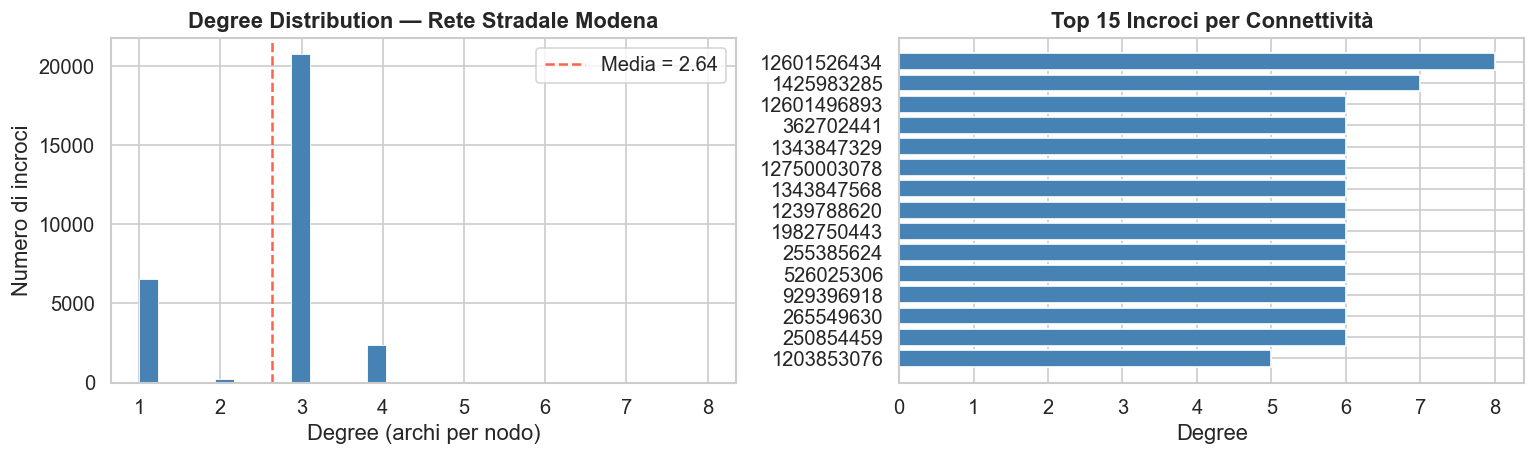

In [17]:
top15 = degree_df.nlargest(15, 'street_count')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(degree_df['street_count'], bins=30,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(degree_df['street_count'].mean(),
                color='tomato', linestyle='--',
                label=f"Media = {degree_df['street_count'].mean():.2f}")
axes[0].set_xlabel('Degree (archi per nodo)')
axes[0].set_ylabel('Numero di incroci')
axes[0].set_title('Degree Distribution — Rete Stradale Modena', fontweight='bold')
axes[0].legend()

# Ordiniamo ascending così con [::-1] il barh mostra il più alto in cima
top15_sorted = top15.sort_values('street_count', ascending=True)
axes[1].barh(top15_sorted['osmid'].astype(str),
             top15_sorted['street_count'], color='steelblue')
axes[1].set_xlabel('Degree')
axes[1].set_title('Top 15 Incroci per Connettività', fontweight='bold')

plt.tight_layout()
plt.show()

La degree distribution rispecchia quello che ci si aspetterebbe ovvero che ogni intersezione abbia in media 1-3-4 strade collegate, e che molto raramente vada più in alto, i valori infatti per degree>4 sono così pochi che non si riescono a visualizzare nell'istogramma.<br>
Questo tipo di distribution è molto differente da grafi che si possono ottenere in altri contesti come Social Network, Wikipedia... dove si presenta una distribuzione classica sbilanciata tra:
- tanti nodi con poca degree
- pochi nodi con altissima degree (influencer / pagine famose)

Visualizziamo la degree a mano per i nodi con degree > 4.

In [18]:
print("=== Incroci con degree > 4 ===")
high_degree = degree_df[degree_df['street_count'] > 4]
print(high_degree['street_count'].value_counts().sort_index())
print(f"\nTotale: {len(high_degree):,} incroci ({len(high_degree)/len(degree_df)*100:.2f}% del totale)")

=== Incroci con degree > 4 ===
street_count
5    35
6    12
7     1
8     1
Name: count, dtype: int64

Totale: 49 incroci (0.16% del totale)


#### Distribuzioni correlate agli archi

In [19]:
road_stats = run_query("""
MATCH ()-[r:ROAD]->()
RETURN r.length AS length,
       r.speed_kph AS speed_kph,
       r.travel_time AS travel_time,
       r.highway AS highway,
       r.oneway AS oneway
""")

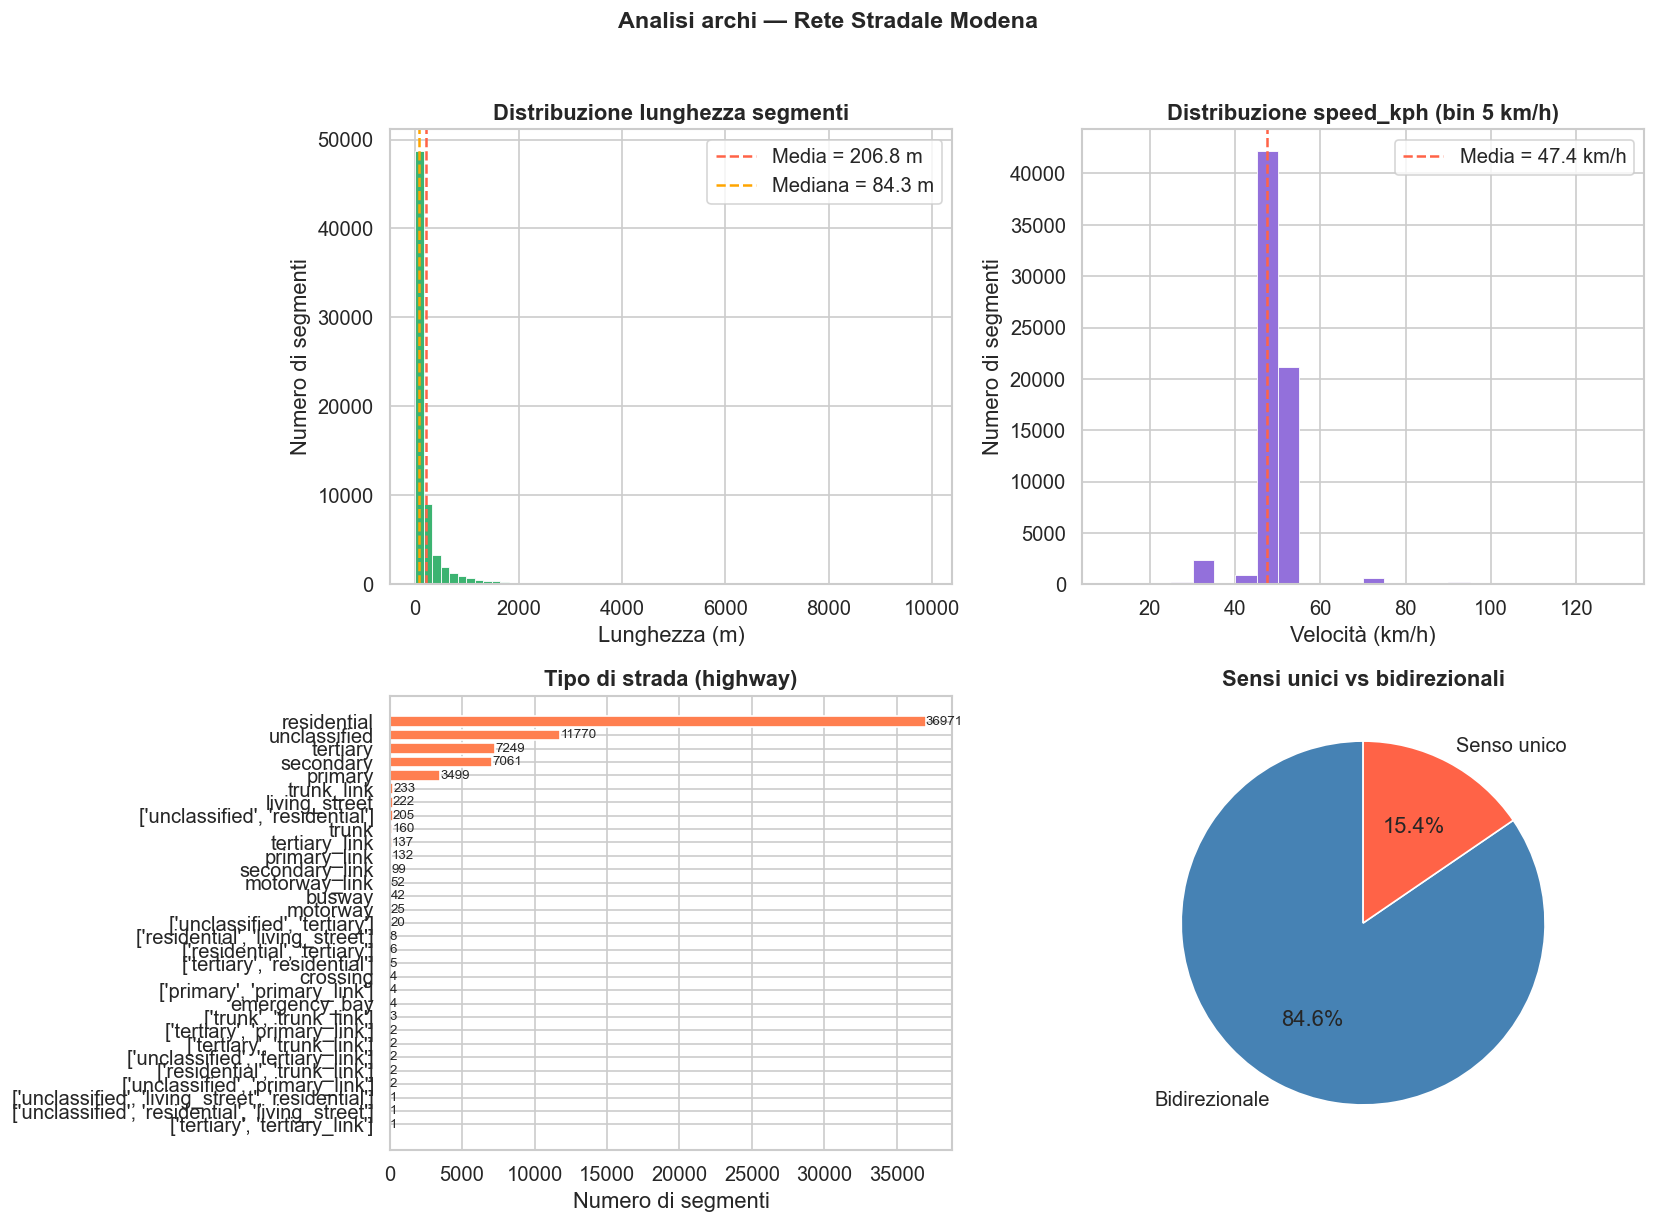

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuzione lunghezza segmenti (istogramma, coda lunga → log su x)
axes[0, 0].hist(road_stats['length'], bins=60,
                color='mediumseagreen', edgecolor='white', linewidth=0.5)
axes[0, 0].axvline(road_stats['length'].mean(), color='tomato', linestyle='--',
                   label=f"Media = {road_stats['length'].mean():.1f} m")
axes[0, 0].axvline(road_stats['length'].median(), color='orange', linestyle='--',
                   label=f"Mediana = {road_stats['length'].median():.1f} m")
axes[0, 0].set_xlabel('Lunghezza (m)')
axes[0, 0].set_ylabel('Numero di segmenti')
axes[0, 0].set_title('Distribuzione lunghezza segmenti', fontweight='bold')
axes[0, 0].legend()

# 2. Distribuzione speed_kph (bin da 5 km/h)
axes[0, 1].hist(road_stats['speed_kph'], 
                bins=range(int(road_stats['speed_kph'].min()), 
                           int(road_stats['speed_kph'].max()) + 5, 5),
                color='mediumpurple', edgecolor='white', linewidth=0.5)
axes[0, 1].set_xlabel('Velocità (km/h)')
axes[0, 1].set_ylabel('Numero di segmenti')
axes[0, 1].set_title('Distribuzione speed_kph (bin 5 km/h)', fontweight='bold')
axes[0, 1].axvline(road_stats['speed_kph'].mean(), color='tomato', linestyle='--',
                   label=f"Media = {road_stats['speed_kph'].mean():.1f} km/h")
axes[0, 1].legend()

# 3. Tipo di strada — barplot orizzontale
highway_counts = road_stats['highway'].value_counts()
axes[1, 0].barh(highway_counts.index[::-1], highway_counts.values[::-1],
                color='coral', edgecolor='white')
axes[1, 0].set_xlabel('Numero di segmenti')
axes[1, 0].set_title('Tipo di strada (highway)', fontweight='bold')
for i, v in enumerate(highway_counts.values[::-1]):
    axes[1, 0].text(v + 20, i, str(v), va='center', fontsize=8)

# 4. Sensi unici — pie chart
oneway_counts = road_stats['oneway'].value_counts()
labels = ['Bidirezionale', 'Senso unico']
axes[1, 1].pie(oneway_counts.values,
               labels=labels,
               autopct='%1.1f%%',
               colors=['steelblue', 'tomato'],
               startangle=90)
axes[1, 1].set_title('Sensi unici vs bidirezionali', fontweight='bold')

plt.suptitle('Analisi archi — Rete Stradale Modena', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Il plot delle distribuzioni mostra che:
- la lunghezza delle strade tra sue intersezioni presenta una distribuzione skewed, motivo per cui la misura di centralità affidabile è la mediana ovvero 84.3 metri.
- la limite di velocità medio è 47.4 km/h anche se bisogna specificare che molte strade non presentavano un limite esplicito catturato da OSM motivo per cui ne è stata fatta una stima sulla base delle strade adiacienti.  (stima fatta da OSM stesso)
- il tipo di strada è principalmente residenziale come è ragionevole che sia
- le strade a senso unico rappresentano solo un 15% del totale

In conclusioni le distribuzioni mostrano dei risultati convincenti in relazione a quello che ci si aspetta infatti:
- il tipo di strada più presente in una città è quello resideziale
- la maggior parte delle strade è a doppio senso
- la velocità media proprio per il primo punto ci si aspetta essere vicino a 50km/h
- la lughezza dei segmenti sempre per il primo punto ci si aspetta una mediana che rispecchi le strade residenziali e con valori alti per le strade secondarie (come la tangenziale), motivo per cui ne risulta una distribuzione skewed

#### Connectivity analysis

Studiamo la connettività del grafo tramite le weakly connected component sfruttando l'implementazione della gds, è una analisi preliminare alle future research question per capire se sarà necessario lanciare futuri algoritmi separatamente sulle varie WCCs.

In [21]:
wcc_df = run_query("""
CALL gds.graph.project.cypher(
  'wcc_check',
  'MATCH (n:Intersection) RETURN id(n) AS id',
  'MATCH (a:Intersection)-[:ROAD]->(b:Intersection) RETURN id(a) AS source, id(b) AS target'
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
print("Proiezione creata:")
print(wcc_df)

wcc_result = run_query("""
CALL gds.wcc.stats('wcc_check')
YIELD componentCount, componentDistribution
RETURN componentCount,
       componentDistribution.min  AS min_size,
       componentDistribution.max  AS max_size,
       componentDistribution.mean AS mean_size,
       componentDistribution.p99  AS p99_size
""")
print("\n=== Weakly Connected Components ===")
print(wcc_result.to_string(index=False))

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.graph.project.cypher(\n  'wcc_check',\n  'MATCH (n:Intersection) RETURN id(n) AS id',\n  'MATCH (a:Intersection)-[:ROAD]->(b:Intersection) RETURN id(a) AS source, id(b) AS target'\n)\nYIELD graphName, nodeCount, relationshipCount\nRETURN graphName, nodeCount, relationshipCount\

Proiezione creata:
   graphName  nodeCount  relationshipCount
0  wcc_check      29941              67924

=== Weakly Connected Components ===
 componentCount  min_size  max_size  mean_size  p99_size
              1     29941     29941    29941.0     29941


Per una rete stradale ci si aspetta proprio che sia totalmente connessa (non avrebbe senso il contrario) ed infatti i risultati confermano questa ipotesi, motivo per cui non sarà necessario in futuro preoccuparsi di avere più WCCs.


Infine rimuovo la proiezione per liberare memoria.

In [22]:
run_query("CALL gds.graph.drop('wcc_check', false) YIELD graphName")
print("Proiezione rimossa")

Proiezione rimossa


## Research Question 1
### Quali sono le macro-zone naturali della rete stradale di Modena?

**Motivazione**

Una rete stradale urbana non è un insieme omogeneo di strade, esistono
zone naturalmente più interconnesse tra loro che con il resto della città,
corrispondenti tipicamente a quartieri, aree residenziali, o zone industriali.
Identificare queste macro-zone ha rilevanza pratica diretta: permette di
capire come è organizzata la mobilità urbana, quali zone sono ben collegate
tra loro e quali invece risultano più isolate.

Questa RQ mira a scoprire la struttura latente della rete attraverso
community detection, caratterizzando poi le zone trovate in termini di
dimensione (numero di nodi) e diametro interno, ovvero quanto è "larga"
ciascuna zona in termini di percorsi stradali.

**Proiezione**

Utilizziamo una proiezione non diretta: la direzione degli archi è
irrilevante per identificare zone geograficamente coese, due incroci
appartengono alla stessa zona indipendentemente dal senso di percorrenza
della strada che li collega. La proiezione è implementata come
**Cypher Projection** esplicita.

**Algoritmi scelti e giustificazione**

| Algoritmo | Categoria | Semantica nel contesto | Giustificazione |
|---|---|---|---|
| **Louvain** | Community | Raggruppa incroci in zone massimizzando la modularità |  In una rete stradale le community corrispondono naturalmente a zone geograficamente coese, alta modularità indica che le strade interne alla zona sono più dense di quelle tra zone diverse |
| **Dimensione community** | Connectivity | Numero di nodi per community | Caratterizza quanto è grande ciascuna zona, permettendo di distinguere community corrispondenti a quartieri densi da zone periferiche con pochi incroci |
| **Diametro per community / Effective diameter** | Connectivity | Longest shortest path interno alla community | Misura quanto è "estesa" ogni zona: una community con diametro alto è geograficamente allungata o con percorsi interni tortuosi, una con diametro basso è compatta e ben connessa internamente |

**Progressione dell'analisi**

L'analisi segue una progressione in cui ogni risultato motiva il passo successivo:

1. **Louvain** → Quante zone naturali ha Modena e quanto sono grandi?
2. **Dimensione** → Le zone sono bilanciate o esistono community dominanti?
3. **Diametro** → Le zone compatte corrispondono al centro storico, quelle con diametro alto alla periferia?


Nodi assegnati: 29,941
Community trovate: 105

=== Dimensione community (top 20) ===
 communityId  size
       16387   614
       23072   578
       16570   526
       12578   460
       15385   458
       24129   453
       13914   451
        7062   442
        3733   439
        7366   438
       19891   437
         616   432
       23907   432
       24509   414
       10631   409
       17735   398
       17913   395
       11541   395
       10471   384
       22244   383

Dimensione media:  285.2 nodi
Dimensione mediana: 272.0 nodi
Community con >500 nodi: 3
Community con <50  nodi: 0


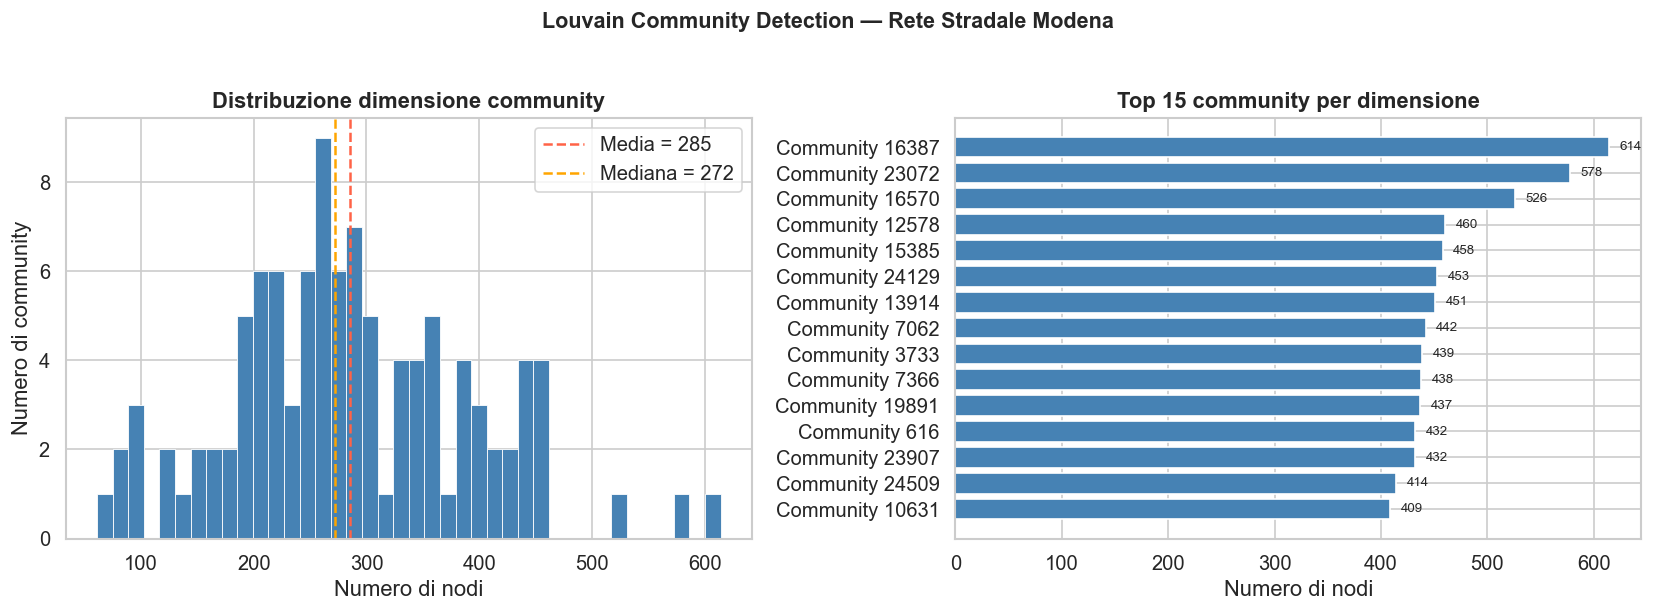

In [23]:
# ── Cypher Projection non diretta per Louvain ────────────────────────────

run_query("CALL gds.graph.drop('rq1_louvain', false) YIELD graphName")

proj = run_query("""
    MATCH (source:Intersection)-[r:ROAD]->(target:Intersection)
    WITH gds.graph.project(
        'rq1_louvain',
        source,
        target,
        {},
        { undirectedRelationshipTypes: ['*'] }
    ) AS g
    RETURN g.graphName, g.nodeCount, g.relationshipCount
""")



# ── Louvain ───────────────────────────────────────────────────────────────
louvain_df = run_query("""
    CALL gds.louvain.stream('rq1_louvain')
    YIELD nodeId, communityId
    RETURN gds.util.asNode(nodeId).osmid AS osmid,
           communityId
    ORDER BY communityId
""")

print(f"\nNodi assegnati: {len(louvain_df):,}")
print(f"Community trovate: {louvain_df['communityId'].nunique()}")

# ── Dimensione community ──────────────────────────────────────────────────
community_sizes = (
    louvain_df.groupby('communityId')
    .size()
    .reset_index(name='size')
    .sort_values('size', ascending=False)
    .reset_index(drop=True)
)

print("\n=== Dimensione community (top 20) ===")
print(community_sizes.head(20).to_string(index=False))
print(f"\nDimensione media:  {community_sizes['size'].mean():.1f} nodi")
print(f"Dimensione mediana: {community_sizes['size'].median():.1f} nodi")
print(f"Community con >500 nodi: {(community_sizes['size'] > 500).sum()}")
print(f"Community con <50  nodi: {(community_sizes['size'] < 50).sum()}")

# ── Plot dimensioni ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Istogramma dimensioni
axes[0].hist(community_sizes['size'], bins=40,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(community_sizes['size'].mean(), color='tomato', linestyle='--',
                label=f"Media = {community_sizes['size'].mean():.0f}")
axes[0].axvline(community_sizes['size'].median(), color='orange', linestyle='--',
                label=f"Mediana = {community_sizes['size'].median():.0f}")
axes[0].set_xlabel('Numero di nodi')
axes[0].set_ylabel('Numero di community')
axes[0].set_title('Distribuzione dimensione community', fontweight='bold')
axes[0].legend()

# Top 15 community per dimensione
top15 = community_sizes.head(15)
axes[1].barh(
    [f"Community {cid}" for cid in top15['communityId']][::-1],
    top15['size'][::-1],
    color='steelblue', edgecolor='white'
)
axes[1].set_xlabel('Numero di nodi')
axes[1].set_title('Top 15 community per dimensione', fontweight='bold')
for i, v in enumerate(top15['size'][::-1]):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=8)

plt.suptitle('Louvain Community Detection — Rete Stradale Modena',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Risultati Louvain — Numero di community

Louvain ha identificato **105 community**, un numero significativamente 
superiore alle 4-8 macro-zone che ci aspettavamo basandoci su una 
corrispondenza con i quartieri amministrativi di Modena.  (modena est modena nord..)

**Perché circa 100 e non 4-8?**

Il risultato è coerente con le proprietà dell'algoritmo e con la natura 
del dataset:

- **Louvain ottimizza la modularità**, non il numero di community. 
  L'algoritmo trova il partizionamento che massimizza la densità interna 
  rispetto alla densità attesa, se la rete ha 105 zone naturalmente dense, 
  Louvain le trova tutte, indipendentemente dalla nostra aspettativa geografica.

- **La rete stradale ha granularità fine**: a differenza di un social network 
  dove le community sono grandi cluster tematici, una rete stradale ha zone 
  dense a livello di singolo quartiere, isolato, o zona residenziale. 
  105 community su 30.000 nodi significa mediamente ~290 incroci per zona, 
  che corrisponde a pochi isolati urbani, una granularità realistica.



**Come interpretare le 105 community**

Piuttosto che un risultato inatteso, le 105 community rappresentano la 
struttura reale della rete a livello di micro-quartieri. L'analisi 
successiva di dimensione e diametro ci dirà se queste community sono 
bilanciate o se esistono poche community dominanti (centro storico) 
e molte piccole community periferiche.

# Analisi delle comunità

Seleziono tre comunità rappresentative: 
- una piccola
- una media 
- una grande <br>


e ne confronto le proprietà strutturali e di accessibilità.

In [24]:
'''
Step implementativi:
- aggiungo community id come proprietà sui nodi (per poter filtrare)
- per ogni community di interesse creo una proiezione ad hoc
- analisi della proiezione per calcolare diametro, effective diameter, densità interna

Per computare il diametro è necessario un ALL-PAIRS SHORTEST PATH, che su grafi di grandi dimensioni può essere molto costoso. 
'''

'\nStep implementativi:\n- aggiungo community id come proprietà sui nodi (per poter filtrare)\n- per ogni community di interesse creo una proiezione ad hoc\n- analisi della proiezione per calcolare diametro, effective diameter, densità interna\n\nPer computare il diametro è necessario un ALL-PAIRS SHORTEST PATH, che su grafi di grandi dimensioni può essere molto costoso. \n'

In [25]:
# ── Step 1: Scrivi communityId sui nodi   (è una write opearations)
print("Scrittura communityId sui nodi...")
records = louvain_df[['osmid', 'communityId']].to_dict('records')
BATCH_SIZE = 500
for i in range(0, len(records), BATCH_SIZE):
    batch = records[i:i + BATCH_SIZE]
    with driver.session(database=NEO4J_DATABASE) as session:
        session.run("""
            UNWIND $batch AS row
            MATCH (n:Intersection {osmid: row.osmid})
            SET n.communityId = row.communityId
        """, batch=batch)

check = run_scalar("""
    MATCH (n:Intersection)
    WHERE n.communityId IS NOT NULL
    RETURN count(n)
""")
print(f"Nodi con communityId settato: {check:,} / {len(louvain_df):,}")

Scrittura communityId sui nodi...
Nodi con communityId settato: 29,941 / 29,941


In [26]:
# ── Selezione community rappresentative ───────────────────────────────

median_size = community_sizes['size'].median()

# community più piccola "significativa"
small_comm = (
    community_sizes[community_sizes['size'] > 50]
    .sort_values('size')
    .head(1)
)

# community più vicina alla mediana
medium_comm = (
    community_sizes.assign(
        dist_from_median=lambda x: abs(x['size'] - median_size)
    )
    .sort_values('dist_from_median')
    .head(1)
)

# community più grande
large_comm = community_sizes.head(1)

target_communities = pd.concat(
    [small_comm, medium_comm, large_comm]
).drop_duplicates(subset=['communityId'])

print("=== Community selezionate ===")
print(target_communities[['communityId', 'size']].to_string(index=False))

=== Community selezionate ===
 communityId  size
       24529    61
       13019   272
       16387   614


Su ciascuna comunità costruiamo una proiezione dedicata e analizziamo:

- densità interna,
- diametro,
- effective diameter,
- lunghezza media dei cammini minimi.

Per le distanze globali sarà necessario un APSP  (all pair shortest path --> ovvero dijkstra multi source)

In [27]:
import numpy as np

# Helper per safe drop
def safe_drop(graph_name):
    run_query(f"CALL gds.graph.drop('{graph_name}', false) YIELD graphName")
    


# Funzione per l'analisi della singola community

def analyze_community(cid, label):

    graph_name = f"comm_{label}_{cid}"
    print(f"\n=== Analisi community {label} (ID={cid}) ===")

    # drop se esiste
    safe_drop(graph_name)

    # ── PROIEZIONE ───────────────────────────────────────────
    proj = run_query(f"""
        CALL gds.graph.project.cypher(
            '{graph_name}',

            // nodi
            'MATCH (n:Intersection)
             WHERE n.communityId = {cid}
             RETURN id(n) AS id',

            // archi
            'MATCH (a:Intersection)-[r:ROAD]->(b:Intersection)
             WHERE a.communityId = {cid}
               AND b.communityId = {cid}
             RETURN id(a) AS source,
                    id(b) AS target,
                    r.travel_time AS weight'
        )
        YIELD graphName, nodeCount, relationshipCount
        RETURN graphName, nodeCount, relationshipCount
    """)

    node_count = int(proj.iloc[0]["nodeCount"])
    edge_count = int(proj.iloc[0]["relationshipCount"])

    print(f"Nodes: {node_count}, Edges: {edge_count}")

    # ── DENSITÀ ─────────────────────────────────────────────
    density = edge_count / (node_count * (node_count - 1)) if node_count > 1 else 0

    # ─────────────────────────────────────────────────────────
    # SHORTEST PATH DISTRIBUTION (Dijkstra multi-source)
    # ─────────────────────────────────────────────────────────
    nodes = run_query(f"""
        MATCH (n:Intersection)
        WHERE n.communityId = {cid}
        RETURN n.osmid AS osmid
    """)["osmid"].tolist()

    all_costs = []

    # ── DISTANZE GLOBALI 

    res = run_query(f"""
    CALL gds.allShortestPaths.stream('{graph_name}', {{
        relationshipWeightProperty: 'weight'
    }})
    YIELD distance

    RETURN distance
    """)

    if res.empty:
        print("Nessun path trovato")
        return None

    costs = res["distance"].values
    costs = np.array(costs)

    # ─────────────────────────────────────────────────────────
    # METRICHE DISTANZA
    # ─────────────────────────────────────────────────────────
    avg_path = costs.mean()
    diameter = costs.max()
    effective_diameter = np.percentile(costs, 90)

    # cleanup
    safe_drop(graph_name)

    return {
        "community": label,
        "communityId": cid,
        "nodes": node_count,
        "edges": edge_count,
        "density": density,
        "avg_path": avg_path,
        "diameter": diameter,
        "effective_diameter": effective_diameter
    }



# ESECUZIONE SULLE 3 COMMUNITY

results = []

for _, row in target_communities.iterrows():
    cid = int(row["communityId"])
    size = int(row["size"])

    if size <= 150:
        label = "small"
    elif abs(size - 260) < 80:
        label = "medium"
    else:
        label = "large"

    res = analyze_community(cid, label)
    if res:
        results.append(res)


results_df = pd.DataFrame(results)

print("\n=== RISULTATI FINALI ===")
print(results_df)


=== Analisi community small (ID=24529) ===


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL gds.graph.project.cypher(\n            'comm_small_24529',\n\n            // nodi\n            'MATCH (n:Intersection)\n             WHERE n.communityId = 24529\n             RETURN id(n) AS id',\n\n            // archi\n            'MATCH (a:Intersection)-[r:ROAD]->(b:Inte

Nodes: 61, Edges: 119

=== Analisi community medium (ID=13019) ===


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL gds.graph.project.cypher(\n            'comm_medium_13019',\n\n            // nodi\n            'MATCH (n:Intersection)\n             WHERE n.communityId = 13019\n             RETURN id(n) AS id',\n\n            // archi\n            'MATCH (a:Intersection)-[r:ROAD]->(b:Int

Nodes: 272, Edges: 642

=== Analisi community large (ID=16387) ===


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL gds.graph.project.cypher(\n            'comm_large_16387',\n\n            // nodi\n            'MATCH (n:Intersection)\n             WHERE n.communityId = 16387\n             RETURN id(n) AS id',\n\n            // archi\n            'MATCH (a:Intersection)-[r:ROAD]->(b:Inte

Nodes: 614, Edges: 1366

=== RISULTATI FINALI ===
  community  communityId  nodes  edges   density    avg_path  diameter  \
0     small        24529     61    119  0.032514  101.985570   384.791   
1    medium        13019    272    642  0.008710   90.774863   464.122   
2     large        16387    614   1366  0.003629  117.778354   325.701   

   effective_diameter  
0            202.1766  
1            162.2818  
2            187.5271  


## Commento complessivo dei risultati

L’analisi delle tre community selezionate (small, medium e large) evidenzia una chiara relazione tra dimensione della community e proprietà strutturali della rete stradale.

Dal punto di vista della densità, si osserva una forte diminuzione all’aumentare della dimensione:
Questo indica che le community più piccole sono più compatte e fortemente connesse internamente, mentre quelle più grandi risultano progressivamente più sparse e meno densamente collegate, il chè risulta logico.

Per quanto riguarda la lunghezza media dei cammini minimi (average path length), si osserva un comportamento molto interessante:
La community media presenta il valore **più basso**, suggerendo una struttura particolarmente efficiente in termini di raggiungibilità interna con strade a percorrenza veloce. La community grande mostra invece distanze significativamente maggiori, dovute alla maggiore estensione geografica e alla probabile presenza di nodi periferici.

L’analisi del diametro e dell'effective diameter conferma questo andamento crescente, come naturale che sia.



### Considerazione finale

Nel complesso, i risultati mostrano che le community individuate non sono solo partizioni topologiche del grafo, ma riflettono anche differenti livelli di organizzazione spaziale della rete stradale.

Le community piccole risultano più dense mentre le community grandi sono più disperse e meno efficienti dal punto di vista della connettività interna. Le community di dimensione intermedia sembrano invece rappresentare il miglior compromesso tra compattezza e copertura spaziale.

--- 

## Research Question 2
### Quali sono gli snodi stradali più critici della rete di Modena?

**Motivazione**

In una rete stradale urbana, non tutti gli incroci hanno la stessa importanza. 
Alcuni incroci sono critici non perché abbiano molte strade (degree alto), 
ma perché si trovano su percorsi che connettono zone diverse della città. <br> 
La chiusura di questi nodi (per lavori, incidenti, o eventi) potrebbe 
causare un disagio sproporzionato alla mobilità urbana, obbligando migliaia 
di percorsi a deviare significativamente.

Questa RQ mira a identificare questi snodi critici attraverso tre metriche 
di centralità complementari, ognuna con una semantica diversa.

**Proiezione**

Utilizziamo una Cypher Projection che include tutti i nodi `Intersection` 
e gli archi `ROAD` pesati con `travel_time` , il tempo di percorrenza in 
secondi è il peso più realistico per modellare il disagio alla mobilità 
(un blocco su una strada veloce impatta più di uno su una strada lenta).

**Algoritmi scelti e giustificazione**

| Algoritmo | Semantica nel contesto | Giustificazione |
|---|---|---|
| **Betweenness Centrality** | Quanti shortest path passano per questo nodo? | È la metrica che ci aspettiamo più informativa per identificare snodi critici: un nodo con alta betweenness è un "collo di bottiglia" , molti percorsi ottimali lo attraversano, quindi la sua rimozione obbliga molte coppie di nodi a ricalcolare il percorso |
| **Closeness Centrality** | Quanto velocemente questo nodo raggiunge tutti gli altri? | Misura l'accessibilità: un nodo con alta closeness è "centrale" geograficamente e la sua chiusura isola zone che erano ben connesse al resto della città |
| **Degree Centrality** | Quante strade convergono in questo incrocio? | È la metrica più semplice: selezionerà  incrocio complessi con molte strade affluenti, non è necessariamente critico se è in una zona periferica.  |

L'ipotesi è che **betweenness centrality** selezioni i nodi più critici in quanto sono quelli che fanno parte della maggior parte dei percorsi minimi, andremo a confrontare i risultati ottenuti e se si assomigliano tra loro,
una eventuale divergenza è essa stessa un risultato interessante.

### Creazione della proiezione

Manteniamo solamente la property travel_time , è l'unica che ci interessa ai fini di questa research question.

In [30]:
# Cypher Projection pesata con travel_time
proj_rq1 = run_query("""
CALL gds.graph.project.cypher(
  'rq1_centrality',
  'MATCH (n:Intersection) RETURN id(n) AS id',
  'MATCH (a:Intersection)-[r:ROAD]->(b:Intersection)
   RETURN id(a) AS source, id(b) AS target, r.travel_time AS travel_time'
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")
print("Proiezione creata:")
print(proj_rq1.to_string(index=False))

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=1, offset=1>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 1, 'line': 2, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\nCALL gds.graph.project.cypher(\n  'rq1_centrality',\n  'MATCH (n:Intersection) RETURN id(n) AS id',\n  'MATCH (a:Intersection)-[r:ROAD]->(b:Intersection)\n   RETURN id(a) AS source, id(b) AS target, r.travel_time AS travel_time'\n)\nYIELD graphName, nodeCount, relationshipCount\nRETURN 

Proiezione creata:
     graphName  nodeCount  relationshipCount
rq1_centrality      29941              67924


Computazione della Betweenness Centrality

In [31]:
betweenness_df = run_query("""
CALL gds.betweenness.stream('rq1_centrality')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).osmid AS osmid,
       gds.util.asNode(nodeId).street_count AS street_count,
       score AS betweenness
ORDER BY betweenness DESC
LIMIT 20
""")

print("=== Top 20 nodi per Betweenness Centrality ===")
print(betweenness_df.to_string(index=False))

=== Top 20 nodi per Betweenness Centrality ===
     osmid  street_count  betweenness
 367089102             3 2.465011e+08
1771842062             3 2.416686e+08
 603014701             3 2.403077e+08
1630899376             4 2.395754e+08
 367092921             3 2.361523e+08
 121994385             3 2.347339e+08
 367080249             3 2.314083e+08
 367089260             3 2.306129e+08
 367092920             3 2.289434e+08
2414642167             3 2.229534e+08
 852704284             3 2.193373e+08
 585415297             3 2.190895e+08
1637404168             3 2.180584e+08
1637645788             3 2.174763e+08
 265549361             4 1.666379e+08
 367092928             3 1.552130e+08
 621892580             3 1.550515e+08
 369616649             3 1.541880e+08
 694566444             3 1.498587e+08
1771842023             3 1.457920e+08


Computazione dela Closeness Centrality

In [32]:
closeness_df = run_query("""
CALL gds.closeness.stream('rq1_centrality')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).osmid AS osmid,
       gds.util.asNode(nodeId).street_count AS street_count,
       score AS closeness
ORDER BY closeness DESC
LIMIT 20
""")

print("=== Top 20 nodi per Closeness Centrality ===")
print(closeness_df.to_string(index=False))

=== Top 20 nodi per Closeness Centrality ===
     osmid  street_count  closeness
 280980332             3   1.000000
1445149084             2   1.000000
 621764897             4   1.000000
1476209439             1   1.000000
1445149082             1   1.000000
 598099283             2   1.000000
 860336654             2   1.000000
 621764899             1   1.000000
1749583389             1   1.000000
 290436930             2   1.000000
 860336651             1   1.000000
1352578086             2   1.000000
2110807132             1   1.000000
6267331780             3   1.000000
 309110533             3   0.800000
 309085367             3   0.666667
 309085364             1   0.500000
 309110534             1   0.500000
 309109532             1   0.444444
 281976459             3   0.017822


Computazione della Degree Centrality

In [33]:
degree_centrality_df = run_query("""
CALL gds.degree.stream('rq1_centrality')
YIELD nodeId, score
RETURN gds.util.asNode(nodeId).osmid AS osmid,
       gds.util.asNode(nodeId).street_count AS street_count,
       score AS degree_centrality
ORDER BY degree_centrality DESC
LIMIT 20
""")

print("=== Top 20 nodi per Degree Centrality ===")
print(degree_centrality_df.to_string(index=False))

=== Top 20 nodi per Degree Centrality ===
     osmid  street_count  degree_centrality
 250854459             6                5.0
 881951237             5                5.0
 929396918             6                5.0
1203853076             5                5.0
1425983285             7                5.0
 483875457             4                4.0
 472479520             4                4.0
 484042631             4                4.0
  82562380             4                4.0
 271241351             4                4.0
 290275666             4                4.0
 472479472             4                4.0
 483875331             4                4.0
 483875408             4                4.0
 283610851             4                4.0
 269759661             4                4.0
 267728510             4                4.0
 270001245             4                4.0
 270003084             4                4.0
 265549599             4                4.0


### Confronto dei risultati

Come detto all'inizio ci aspettiamo che i nodi ritornati da betweenness siano significativamente diversi dalla degree centrality.

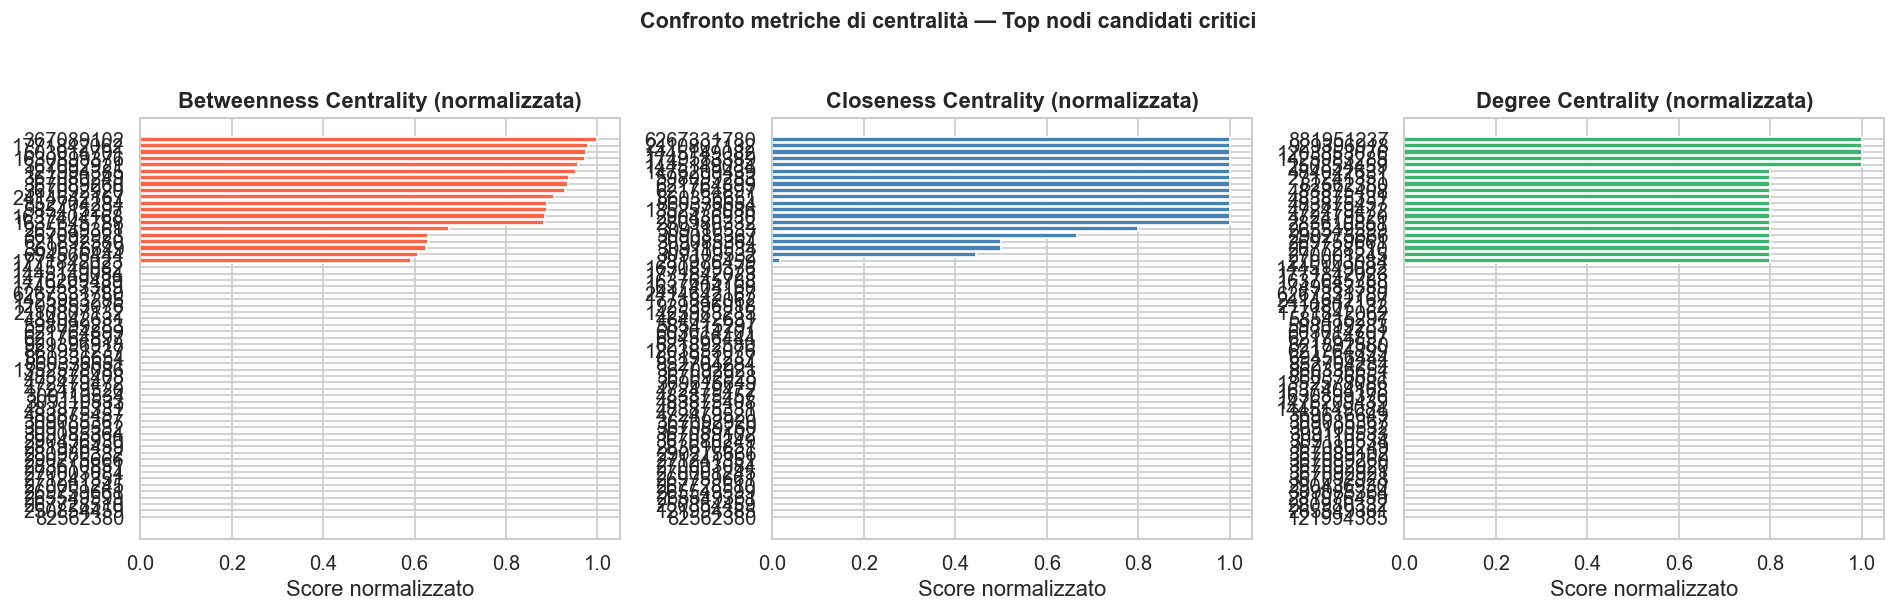

In [34]:
# Merge sui top 20 di betweenness (i candidati più critici)
comparison_df = betweenness_df[['osmid', 'betweenness']].merge(
    closeness_df[['osmid', 'closeness']], on='osmid', how='outer'
).merge(
    degree_centrality_df[['osmid', 'degree_centrality']], on='osmid', how='outer'
).fillna(0)

# Normalizziamo 0-1 per renderle confrontabili
for col in ['betweenness', 'closeness', 'degree_centrality']:
    comparison_df[f'{col}_norm'] = (
        comparison_df[col] - comparison_df[col].min()
    ) / (comparison_df[col].max() - comparison_df[col].min())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('betweenness_norm', 'Betweenness', 'tomato'),
    ('closeness_norm',   'Closeness',   'steelblue'),
    ('degree_centrality_norm', 'Degree', 'mediumseagreen')
]

for ax, (col, label, color) in zip(axes, metrics):
    sorted_df = comparison_df.sort_values(col, ascending=True)
    ax.barh(sorted_df['osmid'].astype(str), sorted_df[col], color=color)
    ax.set_title(f'{label} Centrality (normalizzata)', fontweight='bold')
    ax.set_xlabel('Score normalizzato')

plt.suptitle('Confronto metriche di centralità — Top nodi candidati critici',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In tutte e 3 le metriche gli score sono alti per alcuni nodi e convergono a 0 per il resto, tuttavia questo plot da solo è poco utile per il confronto reale, motivo per cui:

### Calcolo la sovrapposizione per avere un valore numerico

In [35]:
top_b = set(betweenness_df['osmid'].head(20))
top_c = set(closeness_df['osmid'].head(20))
top_d = set(degree_centrality_df['osmid'].head(20))

overlap_all   = top_b & top_c & top_d
overlap_bc    = top_b & top_c - top_d
only_b        = top_b - top_c - top_d

print(f"Top 20 in Betweenness E Closeness:        {len(overlap_bc)} nodi")
print(f"\nOverlap tra tutte e 3 le metriche: {len(overlap_all)} ")

Top 20 in Betweenness E Closeness:        0 nodi

Overlap tra tutte e 3 le metriche: 0 


L'inesistenza di overlap tra le 3 analisi mostra come effettivamente queste tre metriche abbiamo una semantica differente come motivato all'inizio

### Come si potrebbe valutare numericamente la criticità di un insieme di incroci?

L'idea è quella di testare che i top 100 nodi critici restituiti dalla betweenness centrality lo siano realmente, un modo empirico di farlo è quello di verificare la lunghezza media dei Shortest path dati dalla nuova rete.

L'ipotesi è che l'ASPL (average shortest path length) aumenti considerevolmente di più nella proiezioni in cui sono stati eliminati i top 100 archi detectati dalla Betweenness centrality e al contrario non un significativo aumento per la proiezione che riguarda la degree centrality.


In [36]:
'''

La funzione project_without(proj_name, excluded_osmids):
    - dato un nome per la proiezione e una lista di osmids da escludere,
     crea una proiezione pesata con travel_time escludendo i nodi specificati.
     [gli osmid da escludere corrispondono a quelli identificati da una delle 3 centrality]

La funzione sample_avg_shortest_path(proiezione,sample):
    - data una delle 3 proiezioni e 100 sample di nodi sorgente, 
    calcola il tempo medio di percorrenza (ASPL) tra tutte le coppie sorgente-destinazione raggiungibili,
     usando come peso travel_time. 

'''


import random

SAMPLE_SIZE = 100  # sorgenti campionate 


def sample_avg_shortest_path(graph_name, sample_size, seed=42):
    nodes = run_query("""
        MATCH (n:Intersection)
        RETURN n.osmid AS osmid
    """)

    random.seed(seed)
    sampled = random.sample(
        nodes['osmid'].dropna().astype(int).tolist(),
        min(sample_size, len(nodes))
    )

    results = run_query(f"""
        MATCH (source:Intersection)
        WHERE source.osmid IN {sampled}
        CALL gds.allShortestPaths.dijkstra.stream('{graph_name}', {{
            sourceNode: source,
            relationshipWeightProperty: 'travel_time'
        }})
        YIELD totalCost
        WHERE totalCost > 0
          AND totalCost < 1e9
        RETURN avg(totalCost) AS avg_travel_time,
               count(totalCost) AS n_paths
    """)

    avg = results['avg_travel_time'].iloc[0]
    n   = results['n_paths'].iloc[0]
    return avg, n



def project_without(proj_name, excluded_osmids):
    run_query(f"CALL gds.graph.drop('{proj_name}', false) YIELD graphName")
    run_query(f"""
        CALL gds.graph.project.cypher(
          '{proj_name}',
          'MATCH (n:Intersection)
           WHERE NOT n.osmid IN {excluded_osmids}
           RETURN id(n) AS id',
          'MATCH (a:Intersection)-[r:ROAD]->(b:Intersection)
           WHERE NOT a.osmid IN {excluded_osmids}
           AND NOT b.osmid IN {excluded_osmids}
           RETURN id(a) AS source, id(b) AS target,
                  r.travel_time AS travel_time'
        )
        YIELD graphName, nodeCount
        RETURN graphName, nodeCount
    """)


In [37]:

# ── Baseline 
print("Calcolo ASPL baseline...")
aspl_baseline, n_baseline = sample_avg_shortest_path('rq1_centrality', SAMPLE_SIZE)
print(f"Baseline — ASPL: {aspl_baseline:.2f}s su {n_baseline:,} path")

# ── Per ogni metrica 
metrics = {
    'Betweenness': betweenness_df.head(100)['osmid'].astype(int).tolist(),
    'Closeness':   closeness_df.head(100)['osmid'].astype(int).tolist(),
    'Degree':      degree_centrality_df.head(100)['osmid'].astype(int).tolist(),
}

aspl_results = {'Baseline': (aspl_baseline, 0.0)}

for metric_name, critical_nodes in metrics.items():
    print(f"Calcolo ASPL senza top 100 {metric_name}...")
    proj_name = f'rq1_no_{metric_name.lower()}'
    project_without(proj_name, critical_nodes)
    aspl, n_paths = sample_avg_shortest_path(proj_name, SAMPLE_SIZE)
    degradation = ((aspl - aspl_baseline) / aspl_baseline) * 100
    aspl_results[metric_name] = (aspl, degradation)
    run_query(f"CALL gds.graph.drop('{proj_name}', false) YIELD graphName")
    print(f"  ASPL: {aspl:.2f}s | path considerati: {n_paths:,} | degradazione: +{degradation:.1f}%")

# ── Riepilogo tabellare 
print("\n=== Impatto rimozione top 100 nodi — ASPL ===")
print(f"{'Metrica':<15} {'ASPL (s)':>10} {'Degradazione':>14}")
print("-" * 42)
for metric, (aspl, deg) in aspl_results.items():
    deg_str = f"+{deg:.1f}%" if deg > 0 else "baseline"
    print(f"{metric:<15} {aspl:>10.2f} {deg_str:>14}")



Calcolo ASPL baseline...
Baseline — ASPL: 2260.27s su 2,990,000 path
Calcolo ASPL senza top 100 Betweenness...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL gds.graph.project.cypher(\n          'rq1_no_betweenness',\n          'MATCH (n:Intersection)\n           WHERE NOT n.osmid IN [367089102, 1771842062, 603014701, 1630899376, 367092921, 121994385, 367080249, 367089260, 367092920, 2414642167, 852704284, 585415297, 1637404168,

  ASPL: 2288.70s | path considerati: 2,986,500 | degradazione: +1.3%
Calcolo ASPL senza top 100 Closeness...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL gds.graph.project.cypher(\n          'rq1_no_closeness',\n          'MATCH (n:Intersection)\n           WHERE NOT n.osmid IN [280980332, 1445149084, 621764897, 1476209439, 1445149082, 598099283, 860336654, 621764899, 1749583389, 290436930, 860336651, 1352578086, 2110807132,

  ASPL: 2264.57s | path considerati: 2,989,900 | degradazione: +0.2%
Calcolo ASPL senza top 100 Degree...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. gds.graph.project.cypher is deprecated. It is replaced by gds.graph.project Cypher projection as an aggregation function.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "\n        CALL gds.graph.project.cypher(\n          'rq1_no_degree',\n          'MATCH (n:Intersection)\n           WHERE NOT n.osmid IN [250854459, 881951237, 929396918, 1203853076, 1425983285, 483875457, 472479520, 484042631, 82562380, 271241351, 290275666, 472479472, 483875331, 4838754

  ASPL: 2318.50s | path considerati: 2,985,000 | degradazione: +2.6%

=== Impatto rimozione top 100 nodi — ASPL ===
Metrica           ASPL (s)   Degradazione
------------------------------------------
Baseline           2260.27       baseline
Betweenness        2288.70          +1.3%
Closeness          2264.57          +0.2%
Degree             2318.50          +2.6%


### Interpretazione ASPL

| Metrica | Degradazione ASPL | 
|---|---|
| Degree | **+2.6%** | 
| Betweenness | +1.3% | 
| Closeness | +0.2% | 

I risultati mostrano che : **Degree è il predittore più forte di
criticità strutturale** nella rete stradale di Modena.

Questo risultato è **controintuitivo rispetto all'ipotesi iniziale**
(ci aspettavamo Betweenness dominante) ma è spiegabile dalla natura
delle reti stradali non considerata inizialmente:

- Le reti stradali sono progettate per la **ridondanza locale** ,
  ogni incrocio ha quasi sempre un percorso alternativo nelle vicinanze.
  Betweenness identifica colli di bottiglia sui percorsi ottimali,
  ma la rete trova facilmente alternative appena più lunghe.

- Gli incroci con alto Degree sono fisicamente complessi: rimuoverli
  elimina simultaneamente molti archi, riducendo le opzioni locali
  in modo più drastico, allungando quindi maggiormente il nuovo path ottimale .
  L'idea è che alto Degree identifica incroci fisicamente complessi dove molte strade convergono e questi in una rete stradale reale  sono spesso incroci in zone dense del centro (mai nei confini) dove le strade alternative sono poche e rimuoverli forza deviazioni reali sui percorsi. È la metrica che cattura meglio la **fragilità locale** della rete.
  E' proprio questo il concetto di criticità che stavamo cercando.

- Closeness misura l'accessibilità media non la criticità, 
  un nodo centrale è circondato da alternative, quindi la sua
  rimozione ha impatto minimo.


#### Ulteriore metrica
Un'altra possibile metrica è fare una analisi di connettività sui 3 nuovi grafi dopo la rimozione delle top100 delle rispettive centralità.

Successivamente confrontiamo non solo quante WCCs si sono create ma anche la loro cardinalità.

=== BASELINE ===
 componentCount  min_size  max_size  mean_size  p75_size
              1     29941     29941    29941.0     29941
Distribuzione componenti:
size
29941    1
Name: count, dtype: int64

=== Rimozione top 100 — Betweenness ===
 componentCount  min_size  max_size  mean_size  p75_size
              4         3     29906     7480.0         8
Componente più grande:          29,906 nodi
Componenti piccole (<100 nodi): 3
Top 10 componenti:
 componentId  size
           0 29906
       14188     8
        6709     3
       23069     3

=== Rimozione top 100 — Closeness ===
 componentCount  min_size  max_size  mean_size  p75_size
              1     29919     29919    29919.0     29919
Componente più grande:          29,919 nodi
Componenti piccole (<100 nodi): 0
Top 10 componenti:
 componentId  size
           0 29919

=== Rimozione top 100 — Degree ===
 componentCount  min_size  max_size  mean_size  p75_size
              4         3     29892    7479.25        14
Componente più g

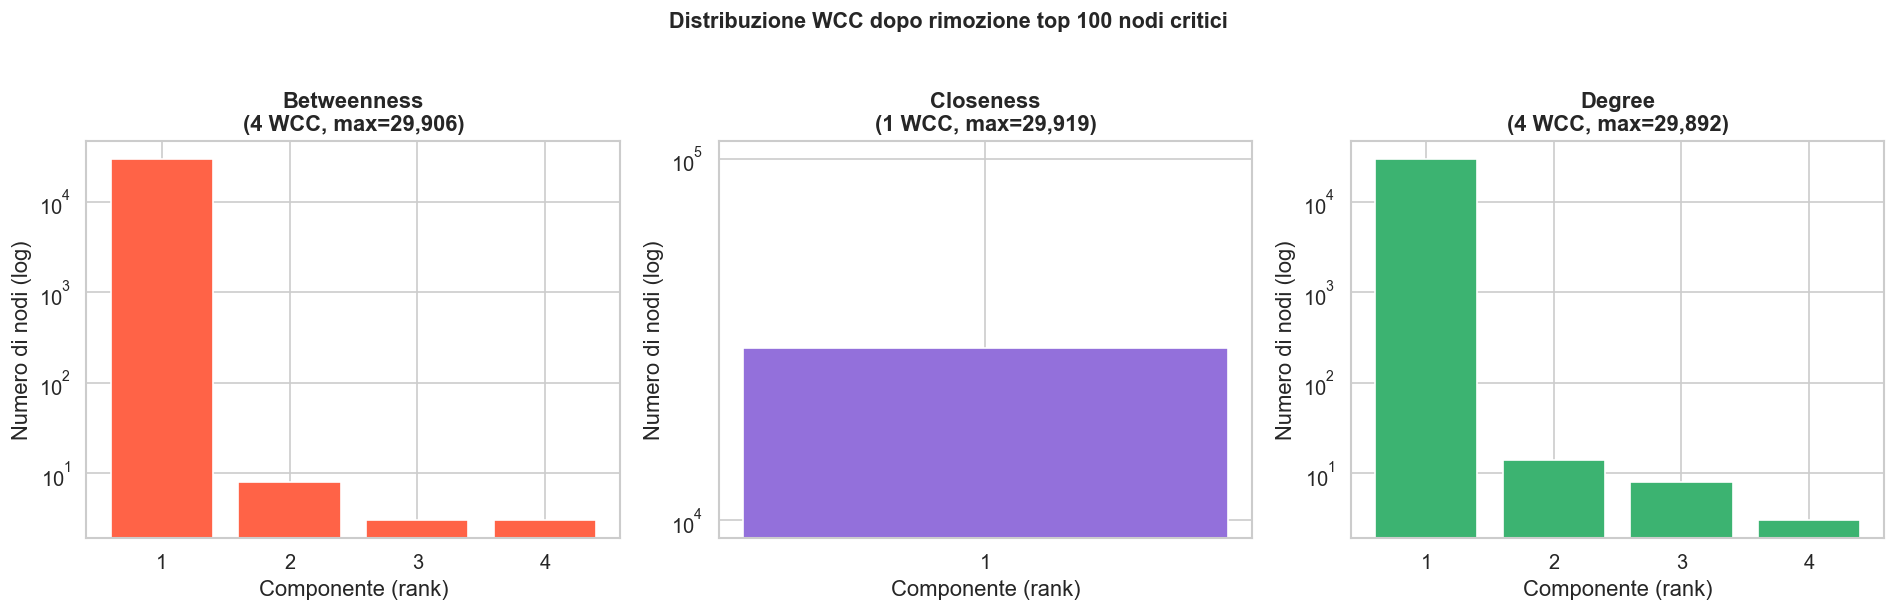

In [38]:
'''
La struttura del codice è analoga alla precedente:

La funzione "project_without_undirected" genera le proiezioni 

La funzione "get_wcc_details" estrae le statistiche sulle WCC e la distribuzione delle dimensioni delle componenti secondo
una determinata proiezione

'''

TOP_N = 100

def project_without_undirected(proj_name, excluded_osmids):
    """Proiezione NON diretta — corretta per WCC."""
    run_query(f"CALL gds.graph.drop('{proj_name}', false) YIELD graphName")
    run_query(f"""
        MATCH (source:Intersection)-[r:ROAD]->(target:Intersection)
        WHERE NOT source.osmid IN {excluded_osmids}
          AND NOT target.osmid IN {excluded_osmids}
        WITH gds.graph.project(
            '{proj_name}',
            source,
            target,
            {{}},
            {{ undirectedRelationshipTypes: ['*'] }}
        ) AS g
        RETURN g.graphName, g.nodeCount, g.relationshipCount
    """)

def get_wcc_details(proj_name):
    stats = run_query(f"""
        CALL gds.wcc.stats('{proj_name}')
        YIELD componentCount, componentDistribution
        RETURN componentCount,
               componentDistribution.min  AS min_size,
               componentDistribution.max  AS max_size,
               componentDistribution.mean AS mean_size,
               componentDistribution.p75  AS p75_size
    """)
    dist = run_query(f"""
        CALL gds.wcc.stream('{proj_name}')
        YIELD nodeId, componentId
        RETURN componentId, count(nodeId) AS size
        ORDER BY size DESC
    """)
    return stats, dist

# ── Baseline (proiezione undirected del grafo completo) 
run_query("CALL gds.graph.drop('rq1_baseline_undirected', false) YIELD graphName")
run_query("""
    MATCH (source:Intersection)-[r:ROAD]->(target:Intersection)
    WITH gds.graph.project(
        'rq1_baseline_undirected',
        source,
        target,
        {},
        { undirectedRelationshipTypes: ['*'] }
    ) AS g
    RETURN g.graphName, g.nodeCount, g.relationshipCount
""")

print("=== BASELINE ===")
stats_before, dist_before = get_wcc_details('rq1_baseline_undirected')
wcc_before  = int(stats_before['componentCount'].iloc[0])
max_before  = int(dist_before['size'].iloc[0])
print(stats_before.to_string(index=False))
print(f"Distribuzione componenti:\n{dist_before['size'].value_counts().sort_index()}\n")
run_query("CALL gds.graph.drop('rq1_baseline_undirected', false) YIELD graphName")

# ── Analisi per metrica 
metrics = {
    'Betweenness': betweenness_df.head(TOP_N)['osmid'].astype(int).tolist(),
    'Closeness':   closeness_df.head(TOP_N)['osmid'].astype(int).tolist(),
    'Degree':      degree_centrality_df.head(TOP_N)['osmid'].astype(int).tolist(),
}

wcc_results = {}

for metric_name, critical_nodes in metrics.items():
    print(f"=== Rimozione top {TOP_N} — {metric_name} ===")
    proj_name = f'rq1_no_{metric_name.lower()}_undir'
    project_without_undirected(proj_name, critical_nodes)

    stats, dist = get_wcc_details(proj_name)
    wcc_after  = int(stats['componentCount'].iloc[0])
    max_comp   = int(dist['size'].iloc[0])
    small_comp = int((dist['size'] < 100).sum())

    wcc_results[metric_name] = {
        'wcc_count':  wcc_after,
        'new_wcc':    wcc_after - wcc_before,
        'max_comp':   max_comp,
        'small_comp': small_comp,
        'dist':       dist
    }

    print(stats.to_string(index=False))
    print(f"Componente più grande:          {max_comp:,} nodi")
    print(f"Componenti piccole (<100 nodi): {small_comp}")
    print(f"Top 10 componenti:\n{dist.head(10).to_string(index=False)}\n")

    run_query(f"CALL gds.graph.drop('{proj_name}', false) YIELD graphName")

# ── Riepilogo tabellare 
print(f"\n=== Impatto rimozione top {TOP_N} nodi per metrica ===")
print(f"{'Metrica':<15} {'WCC':>6} {'Nuove WCC':>10} {'Max comp':>10} {'Comp <100':>10}")
print("-" * 55)
print(f"{'Baseline':<15} {wcc_before:>6} {'—':>10} {max_before:>10,} {'—':>10}")
for metric, r in wcc_results.items():
    print(f"{metric:<15} {r['wcc_count']:>6} {r['new_wcc']:>10} "
          f"{r['max_comp']:>10,} {r['small_comp']:>10}")

# ── Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['tomato', 'mediumpurple', 'mediumseagreen']

for ax, (metric_name, r), color in zip(axes, wcc_results.items(), colors):
    dist = r['dist'].head(15)
    ax.bar(range(len(dist)), dist['size'], color=color, edgecolor='white')
    ax.set_title(f'{metric_name}\n({r["wcc_count"]} WCC, max={r["max_comp"]:,})',
                 fontweight='bold')
    ax.set_xlabel('Componente (rank)')
    ax.set_ylabel('Numero di nodi (log)')
    ax.set_yscale('log')
    ax.set_xticks(range(len(dist)))
    ax.set_xticklabels([str(i+1) for i in range(len(dist))])

plt.suptitle(f'Distribuzione WCC dopo rimozione top {TOP_N} nodi critici',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Questa metrica mostra l'analisi di connettività dopo aver rimosso i top 100 incroci critici:
- la closeness si mostra definitivamente essere una misura di centralità non adatta a spiegare la Criticità di un incrocio
- la Degree anche in questo caso (ma meno impattante rispetto a prima) è la più critica andando a creare 3 nuove WCCs di cardinalità maggiore rispetto alla betweenness 

## **Conclusione RQ2:** <br>
Per la pianificazione della resilienza urbana
a Modena: 
- **gli incroci con alto numero di strade convergenti (Degree) rappresentano la vulnerabilità infrastrutturale primaria**


In [29]:
run_query("CALL gds.graph.drop('rq1_centrality', false) YIELD graphName")
run_query("CALL gds.graph.drop('rq1_no_critical_degree', false) YIELD graphName")
run_query("CALL gds.graph.drop('rq1_no_critical', false) YIELD graphName")
run_query("CALL gds.graph.drop('rq1_no_critical_closeness', false) YIELD graphName")
run_query("CALL gds.graph.drop('rq1_no_critical_degree', false) YIELD graphName")
print("Proiezioni rimossa")

Proiezioni rimossa


---

## Research Question 3  
### Quali sono le strade essenziali per mantenere connessa la rete stradale di Modena?

### Motivazione

In una rete stradale urbana, non tutte le strade hanno la stessa importanza strutturale.  
Alcune connessioni risultano fondamentali per garantire la connettività globale della rete.

Questa research question mira a identificare lo **scheletro minimo della rete stradale**, ovvero l’insieme di strade essenziali che mantengono la connettività globale del grafo.


### Strategia:

Per rispondere alla domanda si utilizza il **Minimum Spanning Tree (MST)**, che permette di estrarre una sottostruttura del grafo che:

- connette tutti gli incroci (nodi)
- minimizza il costo totale degli archi (tempo di percorrenza)
- elimina le ridondanze strutturali della rete

Nel nostro caso, il peso degli archi è rappresentato da `travel_time`, poiché è la misura più realistica dell’impatto sulla mobilità urbana.


### Interpretazione del MST

Il Minimum Spanning Tree rappresenta una versione semplificata della rete:

- mantiene solo le connessioni strettamente necessarie
- elimina percorsi alternativi e ridondanti
- evidenzia le strade strutturalmente essenziali

Da un punto di vista urbano, il MST rappresenta una rete ideale “minima” che garantisce comunque la connessione tra tutte le zone della città.


### Valutazione della perdita di efficienza

Una volta estratto il MST, si confronta la sua struttura con la rete originale per valutare il degrado della qualità della viabilità.

In particolare, vengono misurate le seguenti metriche:

- **diametro**
- **effective diameter**
- **average shortest path length (su campionamento di nodi)**


L’analisi del MST non ha solo uno scopo algoritmico, ma permette di evidenziare la differenza tra:

- rete reale urbana (ridondante e robusta)
- rete minima teorica (efficiente ma fragile)

Questa differenza è fondamentale per comprendere la resilienza della rete stradale.

Ci si aspetta che:

- il diametro aumenti significativamente
- l’effective diameter cresca in modo evidente
- la lunghezza media dei cammini aumenti

Questo evidenzia il trade-off tra:
- ridondanza della rete (robustezza)
- efficienza strutturale minima (MST)

In [39]:
# ── DROP se esiste ─────────────────────────────────────────────
run_query("CALL gds.graph.drop('rq3_mst', false) YIELD graphName")

# ── PROIEZIONE GRAFO STRADALE ──────────────────────────────────
proj = run_query("""
CALL gds.graph.project(
    'rq3_mst',
    'Intersection',
    {
        ROAD: {
            orientation: 'UNDIRECTED',
            properties: 'travel_time'
        }
    }
)
YIELD graphName, nodeCount, relationshipCount
RETURN graphName, nodeCount, relationshipCount
""")

print(proj)

  graphName  nodeCount  relationshipCount
0   rq3_mst      29941             135848


Computazione dell' MST

In [40]:
# ── Nodo sorgente: prendiamo il nodo con osmid più basso come starting point
source_node = run_scalar("""
    MATCH (n:Intersection)
    RETURN n.osmid AS osmid
    ORDER BY osmid ASC
    LIMIT 1
""")
print(f"Nodo sorgente MST: {source_node}")

# MST con gds.spanningTree.stream 
mst_df = run_query(f"""
    MATCH (source:Intersection {{osmid: {source_node}}})
    CALL gds.spanningTree.stream('rq3_mst', {{
        sourceNode: source,
        relationshipWeightProperty: 'travel_time'
    }})
    YIELD nodeId, parentId, weight
    RETURN gds.util.asNode(nodeId).osmid  AS osmid,
           gds.util.asNode(parentId).osmid AS parent_osmid,
           weight AS travel_time
    ORDER BY weight DESC
""")

print(f"\nArchi nel MST: {len(mst_df):,}")
print(f"Peso totale MST (travel_time): {mst_df['travel_time'].sum():.1f} s")
print(f"Peso medio arco MST:           {mst_df['travel_time'].mean():.1f} s")
print(f"\nTop 10 archi più pesanti (strade lente/lunghe essenziali):")
print(mst_df.head(10).to_string(index=False))

Nodo sorgente MST: 13886102

Archi nel MST: 29,941
Peso totale MST (travel_time): 341010.4 s
Peso medio arco MST:           11.4 s

Top 10 archi più pesanti (strade lente/lunghe essenziali):
     osmid  parent_osmid  travel_time
 682259517     496248488      503.840
1784422905    1784423621      478.491
1346347239    1345325781      445.067
 766135606     576163930      440.276
1476818896    1297266972      415.446
 860042527    1727449735      383.088
1411097396    1405753709      286.803
1752205735    1751460810      281.190
1730454837     579335498      268.411
1731774272     579335801      267.551


Un primo confronto:


=== MST vs Grafo completo ===
Archi grafo completo: 67,924
Archi MST:            29,941  (44.1% del totale)
Peso totale grafo:    1072448.1 s
Peso totale MST:      341010.4 s (31.8% del totale)


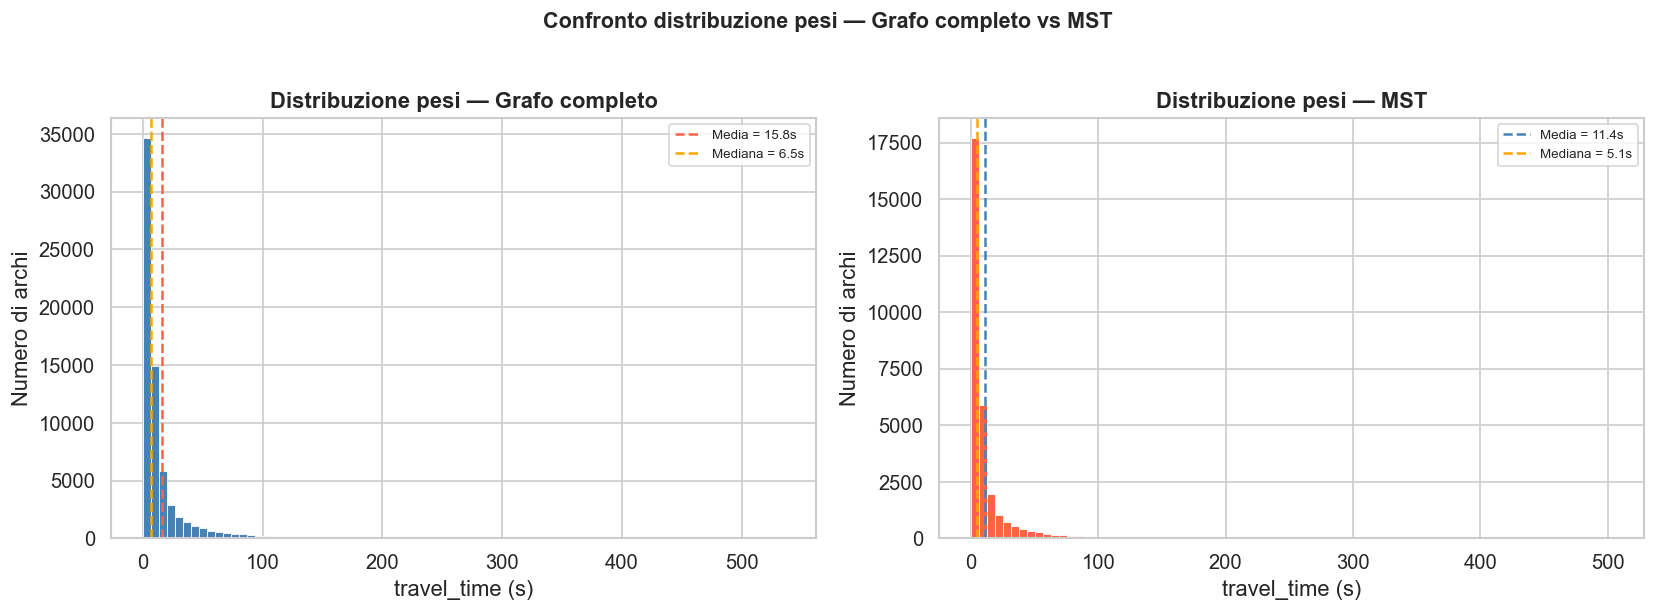

<Figure size 768x576 with 0 Axes>

                         Grafo completo          MST
----------------------------------------------------
Media (s)                          15.8         11.4
Mediana (s)                         6.5          5.1
Std (s)                            28.8         20.2
Max (s)                           535.3        503.8
Min (s)                             0.0          0.0


<Figure size 768x576 with 0 Axes>

In [41]:
# ── Confronto MST vs grafo completo 
total_edges = run_scalar("MATCH ()-[r:ROAD]->() RETURN count(r)")
total_weight = run_scalar("MATCH ()-[r:ROAD]->() RETURN sum(r.travel_time)")

print(f"\n=== MST vs Grafo completo ===")
print(f"Archi grafo completo: {total_edges:,}")
print(f"Archi MST:            {len(mst_df):,}  ({len(mst_df)/total_edges*100:.1f}% del totale)")
print(f"Peso totale grafo:    {total_weight:.1f} s")
print(f"Peso totale MST:      {mst_df['travel_time'].sum():.1f} s ({mst_df['travel_time'].sum()/total_weight*100:.1f}% del totale)")

# Recupera pesi grafo completo
full_weights = run_query("""
    MATCH ()-[r:ROAD]->()
    RETURN r.travel_time AS travel_time
""")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Grafico 1: Grafo completo ─────────────────────────────────────────────
axes[0].hist(full_weights['travel_time'], bins=80,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(full_weights['travel_time'].mean(), color='tomato', linestyle='--',
                label=f"Media = {full_weights['travel_time'].mean():.1f}s")
axes[0].axvline(full_weights['travel_time'].median(), color='orange', linestyle='--',
                label=f"Mediana = {full_weights['travel_time'].median():.1f}s")
axes[0].set_xlabel('travel_time (s)')
axes[0].set_ylabel('Numero di archi')
axes[0].set_title('Distribuzione pesi — Grafo completo', fontweight='bold')
axes[0].legend(fontsize=8)

# ── Grafico 2: MST ────────────────────────────────────────────────────────
axes[1].hist(mst_df['travel_time'], bins=80,
             color='tomato', edgecolor='white', linewidth=0.5)
axes[1].axvline(mst_df['travel_time'].mean(), color='steelblue', linestyle='--',
                label=f"Media = {mst_df['travel_time'].mean():.1f}s")
axes[1].axvline(mst_df['travel_time'].median(), color='orange', linestyle='--',
                label=f"Mediana = {mst_df['travel_time'].median():.1f}s")
axes[1].set_xlabel('travel_time (s)')
axes[1].set_ylabel('Numero di archi')
axes[1].set_title('Distribuzione pesi — MST', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Confronto distribuzione pesi — Grafo completo vs MST',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Annotazioni statistiche
for i, (data, label) in enumerate(zip(
    [full_weights['travel_time'], mst_df['travel_time']],
    ['Completo', 'MST']
), start=1):
    axes[1].text(i, data.max() * 0.95,
                 f"μ={data.mean():.1f}s\nσ={data.std():.1f}s",
                 ha='center', fontsize=8)

plt.suptitle('Confronto distribuzione pesi — Grafo completo vs MST',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'':20} {'Grafo completo':>18} {'MST':>12}")
print("-" * 52)
for stat, f, m in [
    ('Media (s)',   full_weights['travel_time'].mean(),   mst_df['travel_time'].mean()),
    ('Mediana (s)', full_weights['travel_time'].median(), mst_df['travel_time'].median()),
    ('Std (s)',     full_weights['travel_time'].std(),    mst_df['travel_time'].std()),
    ('Max (s)',     full_weights['travel_time'].max(),    mst_df['travel_time'].max()),
    ('Min (s)',     full_weights['travel_time'].min(),    mst_df['travel_time'].min()),
]:
    print(f"{stat:20} {f:>18.1f} {m:>12.1f}")

# Confronto archi e peso MST vs grafo completo
categories = ['Grafo completo', 'MST']
axes[1].bar(categories,
            [total_edges, len(mst_df)],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_ylabel('Numero di archi')
axes[1].set_title('Archi: Grafo completo vs MST', fontweight='bold')
for i, v in enumerate([total_edges, len(mst_df)]):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Minimum Spanning Tree — Rete Stradale Modena',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Da un primo confronto si riescono ad ottenere informazioni interessanti;

Il confronto rivela una struttura interessante: per mantenere la connettività 
globale della rete è sufficiente meno della metà delle strade esistenti (44.1%), 
con un peso totale che scende al 31.8% di quello originale. Questo significa che 
la rete stradale di Modena è significativamente ridondante, una proprietà 
desiderabile per la robustezza urbana, ma che evidenzia come gran parte 
dell'infrastruttura serva a garantire percorsi alternativi piuttosto che 
connettività di base.

È importante sottolineare che il MST rappresenta un costrutto teorico, 
non una soluzione praticabile, il valore dell'analisi sta nel comprendere quali strade costituiscono 
l'ossatura essenziale della mobilità modenese.

Confronto quindi come è cambiata la viabilità globale della rete stradale

1) Per farlo aggiungo una property ad ogni arco per sapere se fa parte dell'MST
2) grazie alla fase precedente creo la proiezione in modo naturale
3) calcolo l'Average Shortest Path length come misura di "viabilità" della rete, essendo una operazione costosa (necessità di un APSP) lo faccio su un campione di 100 nodi come in precedenza, effetto nuovamente il calcolo sul grafo completo (anche se già fatto in una RQ precedente) per ottenere anche il diametro

Write sul grafo (aggiunge property MST_ROAD agli archi)

In [42]:
# ── Proiezione MST su Neo4j ───────────────────────────────────────────────
# Scriviamo gli archi del MST come relazioni separate per poterli proiettare
print("Scrittura archi MST sul grafo...")

mst_records = mst_df[['osmid', 'parent_osmid', 'travel_time']].to_dict('records')

# Pulizia archi MST precedenti se esistono
run_query("MATCH ()-[r:MST_ROAD]->() DELETE r")

for i in range(0, len(mst_records), 500):
    batch = mst_records[i:i+500]
    with driver.session(database=NEO4J_DATABASE) as session:
        session.run("""
            UNWIND $batch AS row
            MATCH (a:Intersection {osmid: row.osmid})
            MATCH (b:Intersection {osmid: row.parent_osmid})
            MERGE (a)-[:MST_ROAD {travel_time: row.travel_time}]->(b)
        """, batch=batch)

check = run_scalar("MATCH ()-[r:MST_ROAD]->() RETURN count(r)")
print(f"Archi MST scritti: {check:,}")

Scrittura archi MST sul grafo...
Archi MST scritti: 29,941


Creo quindi la proiezione come semplice filtro sulla property creata

In [43]:
# ── Proiezione GDS del MST ────────────────────────────────────────────────
run_query("CALL gds.graph.drop('rq_mst_analysis', false) YIELD graphName")

proj_mst = run_query("""
    MATCH (source:Intersection)-[r:MST_ROAD]->(target:Intersection)
    WITH gds.graph.project(
        'rq_mst_analysis',
        source,
        target,
        { relationshipProperties: r { .travel_time } },
        { undirectedRelationshipTypes: ['*'] }
    ) AS g
    RETURN g.graphName, g.nodeCount, g.relationshipCount
""")
print("Proiezione MST creata:")
print(proj_mst.to_string(index=False))

Proiezione MST creata:
    g.graphName  g.nodeCount  g.relationshipCount
rq_mst_analysis        29941                59882


Calcolo gli ASPL tramite la funzione già definita

In [44]:
# ── ASPL baseline già calcolato in precedenza ─────────────────────────────
aspl_baseline = 2260.05


# ── ASPL sul MST ──────────────────────────────────────────────────────────
print("Calcolo ASPL su MST...")
aspl_mst, n_mst = sample_avg_shortest_path('rq_mst_analysis', SAMPLE_SIZE)
degradation = (aspl_mst - aspl_baseline) / aspl_baseline * 100

print(f"\n{'Metrica':<25} {'Grafo completo':>16} {'MST':>12} {'Degradazione':>14}")
print("-" * 68)
print(f"{'ASPL (s)':<25} {aspl_baseline:>16.2f} {aspl_mst:>12.2f} {degradation:>+13.1f}%")

Calcolo ASPL su MST...

Metrica                     Grafo completo          MST   Degradazione
--------------------------------------------------------------------
ASPL (s)                           2260.05      5008.92        +121.6%


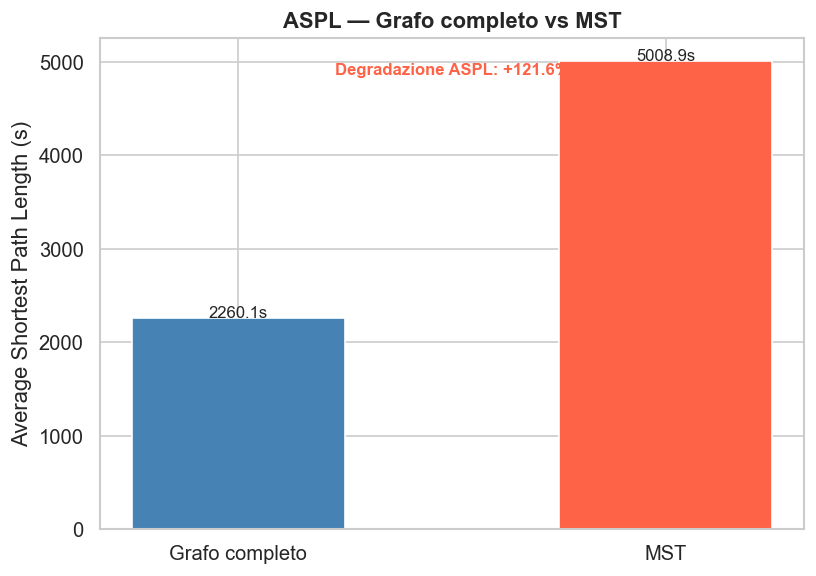

""


In [45]:


# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Grafo completo', 'MST'],
              [aspl_baseline, aspl_mst],
              color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [aspl_baseline, aspl_mst]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{val:.1f}s', ha='center', fontsize=10)
ax.text(0.5, 0.95, f'Degradazione ASPL: {degradation:+.1f}%',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=10, color='tomato', fontweight='bold')
ax.set_ylabel('Average Shortest Path Length (s)')
ax.set_title('ASPL — Grafo completo vs MST', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Cleanup ───────────────────────────────────────────────────────────────
run_query("CALL gds.graph.drop('rq_mst_analysis', false) YIELD graphName")
run_query("MATCH ()-[r:MST_ROAD]->() DELETE r")

Il risultato è netto: ridurre la rete allo scheletro minimo più che raddoppia 
il tempo medio di percorrenza tra due punti qualsiasi della città (+121.6%). 
Questo dato quantifica concretamente il valore della ridondanza stradale: 
le strade "extra" rispetto al minimo indispensabile non sono sprechi 
infrastrutturali, ma il meccanismo che mantiene la mobilità urbana **efficiente** oltre che robusta.

In altre parole, il 55.9% degli archi esclusi dal MST,pur non essendo 
necessari per la connettività è responsabile della metà del tempo 
risparmiato in ogni spostamento urbano. Questo evidenzia un trade-off 
fondamentale nella progettazione delle reti stradali: 
ogni strada "ridondante" aggiunta alla rete minima contribuisce 
a ridurre significativamente i tempi di percorrenza medi.

## Conclusioni

Questo progetto ha analizzato la rete stradale di Modena attraverso tre 
research question, ciascuna con una prospettiva diversa sulla struttura 
e la funzionalità della rete.

### RQ1 — Quali sono le macro-zone naturali della rete stradale di Modena?

L'algoritmo di Louvain ha identificato oltre 100 community, una granularità 
più fine rispetto alle macro-zone amministrative attese. Questo risultato 
riflette la struttura reale della rete: la mobilità urbana si organizza 
naturalmente a livello di micro-quartiere piuttosto che di grande zona. 
L'analisi di diametro e densità interna ha mostrato che le community 
più piccole tendono ad essere più compatte e dense, mentre le community 
di maggiori dimensioni presentano diametri elevati e densità inferiore, 
coerentemente con zone periferiche a sviluppo lineare (strade di 
collegamento senza griglia urbana densa).

### RQ2 — Quali sono gli snodi stradali più critici della rete di Modena?

L'analisi di centralità ha prodotto un risultato controintuitivo rispetto 
all'ipotesi iniziale: Degree Centrality si è rivelata il predittore più 
forte di criticità strutturale, generando la maggior degradazione dell'ASPL 
(+2.6%). Betweenness Centrality, pur identificando i colli di bottiglia sui 
percorsi ottimali, beneficia della ridondanza della rete che offre percorsi 
alternativi quasi equivalenti. Closeness Centrality si è confermata la 
metrica meno adatta a predire la fragilità strutturale in una road network.

### RQ3 — Quali sono le strade essenziali per mantenere connessa la rete?

L'analisi del Minimum Spanning Tree ha mostrato che la connettività globale 
della rete è garantita da meno della metà delle strade esistenti (44.1%), 
con un peso totale che scende al 31.8% dell'originale. Tuttavia il costo 
in termini di efficienza è elevato: l'ASPL più che raddoppia (+121.6%), 
confermando che la ridondanza stradale non è uno spreco infrastrutturale 
ma il meccanismo che rende la mobilità urbana efficiente e resiliente.

### Osservazione trasversale

I tre risultati convergono verso una conclusione comune: la rete stradale 
di Modena è una rete robusta e ridondante per design. Questa ridondanza 
si manifesta nella resistenza alla rimozione di nodi critici (RQ2 in cui l'ASPL non diminuisce significativamente), 
nella struttura a micro-zone densamente connesse (RQ1), e nel divario 
tra rete minima e rete reale (RQ3). La ridondanza ha un costo in termini 
di infrastruttura, ma è il prezzo della resilienza urbana.